## Initializing

In [2]:
# !nvidia-smi

In [1]:
# Imports
import os, pickle, torch
import matplotlib.pyplot as plt
from tqdm import tqdm
from transformers import AutoModelForCausalLM, AutoTokenizer, TextIteratorStreamer
import matplotlib.colors as pltc
import numpy as np
import torch.optim as optim
from torch.utils.tensorboard import SummaryWriter
import datetime
import time
LOCATION = '/igli/raw_logits_v2/'
device = 'cuda:0'

In [2]:
tokenizer = AutoTokenizer.from_pretrained('google/gemma-2b')

In [3]:
class quantizer_4b_torch:
    
    def quantize(self,a): # it is assumed that the distribution of the values is normal
        is_negative=torch.sign(a)<0
        
        x=torch.sqrt(torch.abs(a))*5.3-2.1
        x=torch.round(x)
        x=torch.clip(x,0,7).to(torch.int8)
        
        x=x+8*is_negative.to(torch.int8)
        return x
    
    def decode(self,x):
        is_negative=x>=8
        a=(( torch.remainder(x,8).to(torch.float16)+2.1)/5.3)**2
        a=a*(1-is_negative.to(torch.int8)*2)
        return a
    
    def quantize_compress(self,a):
        ind=self.quantize(a)
        comp=ind[:,0::2]*16+ind[:,1::2]
        return comp.to(torch.uint8)

    def load_decode(self,data):
        ind=torch.zeros((data.shape[0],data.shape[1]*2),dtype=torch.uint8,device=data.device)
        ind[:,0::2]=torch.floor_divide(data,16)
        ind[:,1::2]=torch.remainder(data,16)
        return self.decode(ind)

class quantizer_2b_torch:
    
    def quantize(self,a): # it is assumed that the distribution of the values is normal
        is_negative=torch.sign(a)<0
        
        x=torch.sqrt(torch.abs(a))*1.63-1
        x=torch.round(x)
        x=torch.clip(x,0,1).to(torch.int8)
        
        x=x+2*is_negative.to(torch.int8)
        return x
    
    def decode(self,x):
        is_negative=x>=2
        a=(( torch.remainder(x,2).to(torch.float16)+1)/1.63)**2
        a=a*(1-is_negative.to(torch.int8)*2)
        return a
    
    def quantize_compress(self,a):
        ind=self.quantize(a)
        comp=ind[:,0::4]*64+ind[:,1::4]*16+ind[:,2::4]*4+ind[:,3::4]*1
        return comp.to(torch.uint8)

    def load_decode(self,data):
        ind=torch.zeros((data.shape[0],data.shape[1]*4),dtype=torch.uint8,device=data.device)
        ind[:,0::4]=torch.remainder(torch.floor_divide(data,64),4)
        ind[:,1::4]=torch.remainder(torch.floor_divide(data,16),4)
        ind[:,2::4]=torch.remainder(torch.floor_divide(data, 4),4)
        ind[:,3::4]=torch.remainder(torch.floor_divide(data, 1),4)
        return self.decode(ind)

class quantizer_1b_torch:
    
    def quantize(self,a):
        is_negative=torch.sign(a)<0
        return (is_negative).to(torch.uint8)
    
    def decode(self,x):
        is_negative=x>=1
        a=torch.remainder(x,1).to(torch.float16)+0.8
        a=a*(1-is_negative.to(torch.int8)*2)
        return a
    
    def quantize_compress(self,a):
        ind=self.quantize(a)
        comp=ind[:,0::8]*128+ind[:,1::8]* 64+ind[:,2::8]* 32+ind[:,3::8]* 16+ind[:,4::8]*  8+ind[:,5::8]*  4+ind[:,6::8]*  2+ind[:,7::8]*  1
        return comp.to(torch.uint8)

    def load_decode(self,data):
        ind=torch.zeros((data.shape[0],data.shape[1]*8),dtype=torch.uint8,device=data.device)
        ind[:,0::8]=torch.remainder(torch.floor_divide(data,128),2)
        ind[:,1::8]=torch.remainder(torch.floor_divide(data, 64),2)
        ind[:,2::8]=torch.remainder(torch.floor_divide(data, 32),2)
        ind[:,3::8]=torch.remainder(torch.floor_divide(data, 16),2)
        ind[:,4::8]=torch.remainder(torch.floor_divide(data,  8),2)
        ind[:,5::8]=torch.remainder(torch.floor_divide(data,  4),2)
        ind[:,6::8]=torch.remainder(torch.floor_divide(data,  2),2)
        ind[:,7::8]=torch.remainder(torch.floor_divide(data,  1),2)
        return self.decode(ind)
    
class quantizer_mixed_torch:
    
    def __init__(self,vector_length):
        self.proportion_4b=1/8
        self.proportion_2b=4/8
        self.proportion_1b=3/8
        self.count_4b=int(round(self.proportion_4b*vector_length))
        self.count_2b=int(round(self.proportion_2b*vector_length))
        self.count_1b=int(round(self.proportion_1b*vector_length))
        self.q4=quantizer_4b_torch()
        self.q2=quantizer_2b_torch()
        self.q1=quantizer_1b_torch()
                
    def quantize(self,a):
        a4=self.q4.quantize(a[:,              : self.count_4b])
        a2=self.q2.quantize(a[:, self.count_4b:-self.count_1b])
        a1=self.q1.quantize(a[:,-self.count_1b:              ])      
        return torch.concatenate([a4,a2,a1],axis=1)
    
    def decode(self,index):
        index4=self.q4.decode(index[:,              : self.count_4b])
        index2=self.q2.decode(index[:, self.count_4b:-self.count_1b])
        index1=self.q1.decode(index[:,-self.count_1b:              ])      
        return torch.concatenate([index4,index2,index1],axis=1)

    def quantize_compress(self,a):
        comp4=self.q4.quantize_compress(a[:,              : self.count_4b])
        comp2=self.q2.quantize_compress(a[:, self.count_4b:-self.count_1b])
        comp1=self.q1.quantize_compress(a[:,-self.count_1b:              ])      
        return torch.concatenate([comp4,comp2,comp1],axis=1)

    def load_decode(self,comp):
        comp4=comp[:, 0                 : self.count_4b*4//8]
        comp2=comp[:, self.count_4b*4//8:-self.count_1b*1//8]
        comp1=comp[:,-self.count_1b*1//8:                   ]
        a4=self.q4.load_decode(comp4)
        a2=self.q2.load_decode(comp2)
        a1=self.q1.load_decode(comp1)
        return torch.concatenate([a4,a2,a1],axis=1)

class representation_whitening_torch:
    
    def fit(self,a):
        self.mn=a.mean(dim=0)
        
        # low memory covariance calculation
        cov=torch.eye(a.shape[1],dtype=torch.float32,device=a.device)*0
        for i in tqdm(range(0,a.shape[0],10000)):
            aslice=(a[i:i+10000,:].to(torch.float32)-self.mn)
            cov+=( aslice.T@aslice)/a.shape[0]
        
        
        s2,self.q=torch.linalg.eigh(cov)
        self.q=self.q.to(torch.float16)
        self.s=torch.sqrt(s2).to(torch.float16)
        
        if self.s[0]<self.s[-1]:
            self.s=torch.flip(self.s,dims=[0])
            self.q=torch.flip(self.q,dims=[1])
       
    def encode(self,a):
        return (a-self.mn)@self.q /self.s
    
    def decode(self,e):
        return (self.s*e)@self.q.T+self.mn
    
    def rescale(self,e):
        return self.s*e
    
    def save_state_dict(self,path):
        torch.save({'mn':self.mn,'q':self.q,'s':self.s}, path)

    def load_state_dict(self,path):
        data=torch.load(path)
        self.mn=data['mn']
        self.q =data['q' ]
        self.s =data['s' ]
        
    def to(self, d):
        self.mn = self.mn.to(d)
        self.q = self.q.to(d)
        self.s = self.s.to(d)

### Others

In [3]:
l=[]
file_no=1
with open(os.path.join(LOCATION,f"{file_no:04d}_emb_s"),   "rb") as f: l.append(f.read())

FileNotFoundError: [Errno 2] No such file or directory: '/igli/raw_logits_v2/0001_emb_s'

In [3]:
a = torch.tensor(np.frombuffer(l[0], dtype=np.float16).reshape(1000*1024,2048)).to('cuda:2').to(torch.float32)[0:500000,:]

In [490]:
a = torch.tensor(np.fromfile("/1tb/0000_2167_student_embeddings", dtype=np.float32).reshape(-1, 2048))

In [491]:
a=a-a.mean(dim=0,keepdims=True)

In [492]:
a.shape

torch.Size([3270, 2048])

In [493]:
U, S, V = torch.svd(a.T,some=True)

In [500]:
V.numpy().tofile('whitening/V')

In [501]:
S.numpy().tofile('whitening/S')

In [503]:
a.numpy().tofile('whitening/a')

In [502]:
S.shape, V.shape

(torch.Size([2048]), torch.Size([3270, 2048]))

In [ ]:
def normalize(level, a):
    mean_normed = a - a.mean(dim=0, keepdims=True)
    if level == 0: # Mean normalizing
        return mean_normed
    U, S, V = torch.svd(a.T, some=True)
    if level == 1: # decorrelated

(-0.003793840727303177,
 0.0047223121975548555,
 -0.003917734522838145,
 0.004598418402019888)

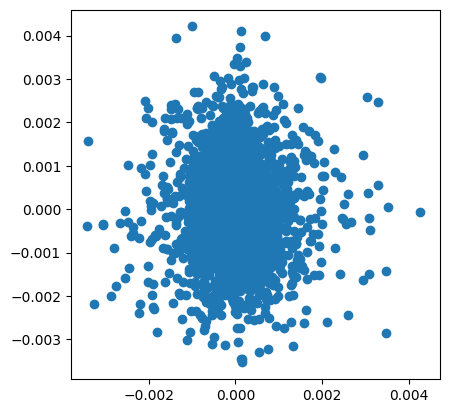

In [27]:
plt.scatter(V.T[:,0].cpu().numpy(), V.T[:,1000].cpu().numpy())
plt.axis('square')

In [179]:
L = []
for k in globals().keys():
    if torch.is_tensor(globals()[k]) and globals()[k].device != torch.device('cpu'):
        print(k)
        L.append(k)
    if hasattr(globals()[k], 'device'):
        L.append(k)
        print(globals()[k].device)

<class 'torch.device'>
cpu
cuda:0
cpu
cpu
cpu
cpu
cpu
cpu
cpu
cpu
cpu
cpu
cpu
cpu
cpu


In [57]:
torch.cuda.empty_cache()
torch.cuda.synchronize()

In [133]:
((U@torch.diag(S)) @ V.T).shape

OutOfMemoryError: CUDA out of memory. Tried to allocate 3.82 GiB. GPU  has a total capacity of 23.64 GiB of which 3.43 GiB is free. Process 12805 has 634.00 MiB memory in use. Including non-PyTorch memory, this process has 19.58 GiB memory in use. Of the allocated memory 19.20 GiB is allocated by PyTorch, and 158.62 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [110]:
torch.mm(torch.mm(U, torch.diag(S)), V.T)

OutOfMemoryError: CUDA out of memory. Tried to allocate 3.82 GiB. GPU  has a total capacity of 23.64 GiB of which 3.43 GiB is free. Process 12805 has 634.00 MiB memory in use. Including non-PyTorch memory, this process has 19.58 GiB memory in use. Of the allocated memory 19.20 GiB is allocated by PyTorch, and 158.62 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [98]:
a[4096:8192,:]@U/S - V[4096:8192,:]

tensor([[ 5.7300e-07,  1.1828e-06, -1.0771e-06,  ..., -1.0025e-07,
          1.2619e-07, -2.2410e-09],
        [ 3.1386e-07, -7.5984e-07, -9.1852e-08,  ...,  7.8311e-08,
         -3.9465e-08,  9.0047e-08],
        [ 2.1508e-08, -1.6454e-06,  3.0996e-07,  ..., -4.4215e-07,
         -1.9255e-07, -7.2899e-07],
        ...,
        [-1.4977e-07, -2.6089e-07,  2.8254e-07,  ...,  5.7649e-07,
         -1.2270e-07, -6.9616e-08],
        [ 8.5420e-08, -3.7195e-07,  3.9919e-07,  ..., -4.4296e-08,
          4.1735e-08, -1.3504e-08],
        [-1.7777e-07,  2.7151e-07,  5.5006e-08,  ...,  2.2480e-07,
         -8.4226e-08,  8.3077e-08]], device='cuda:2')

In [483]:
V

NameError: name 'V' is not defined

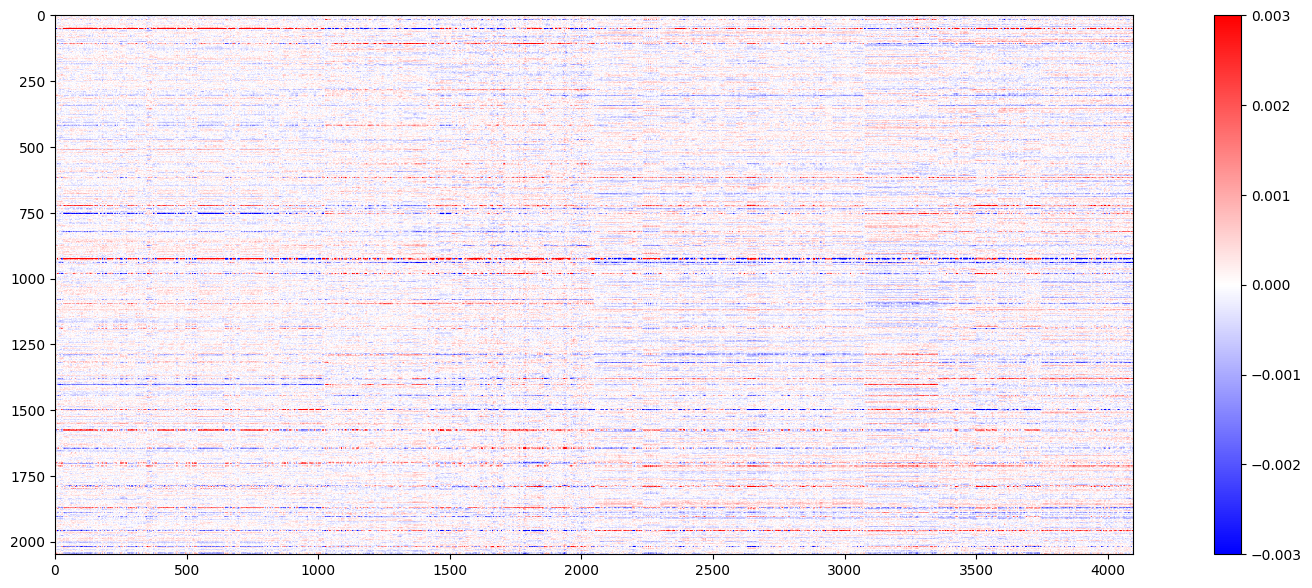

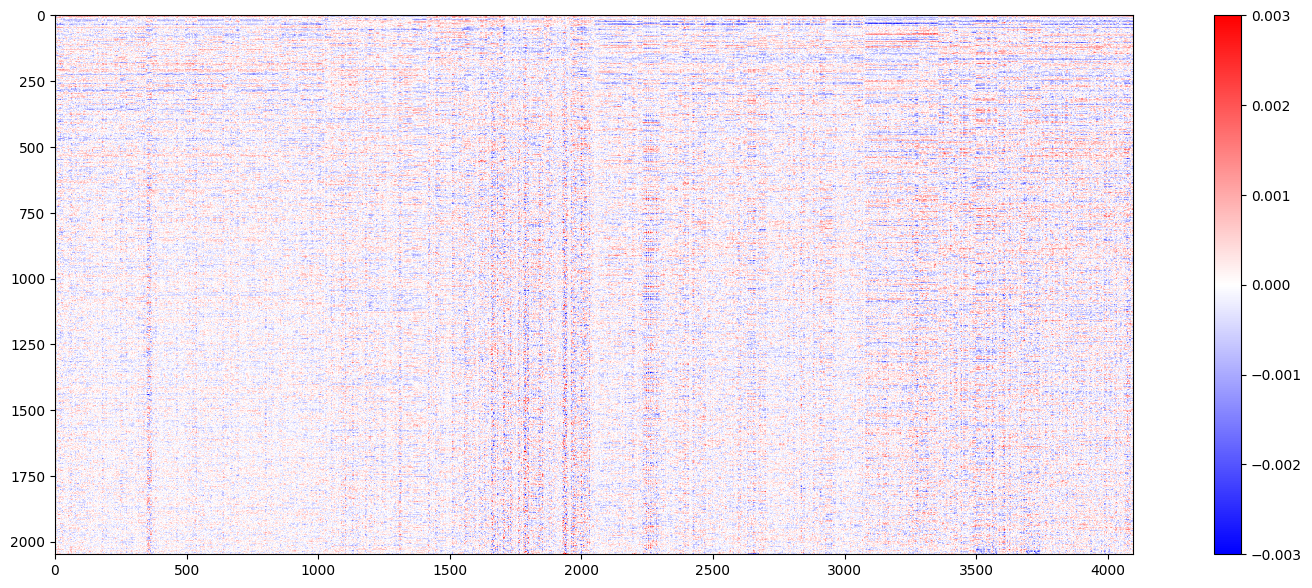

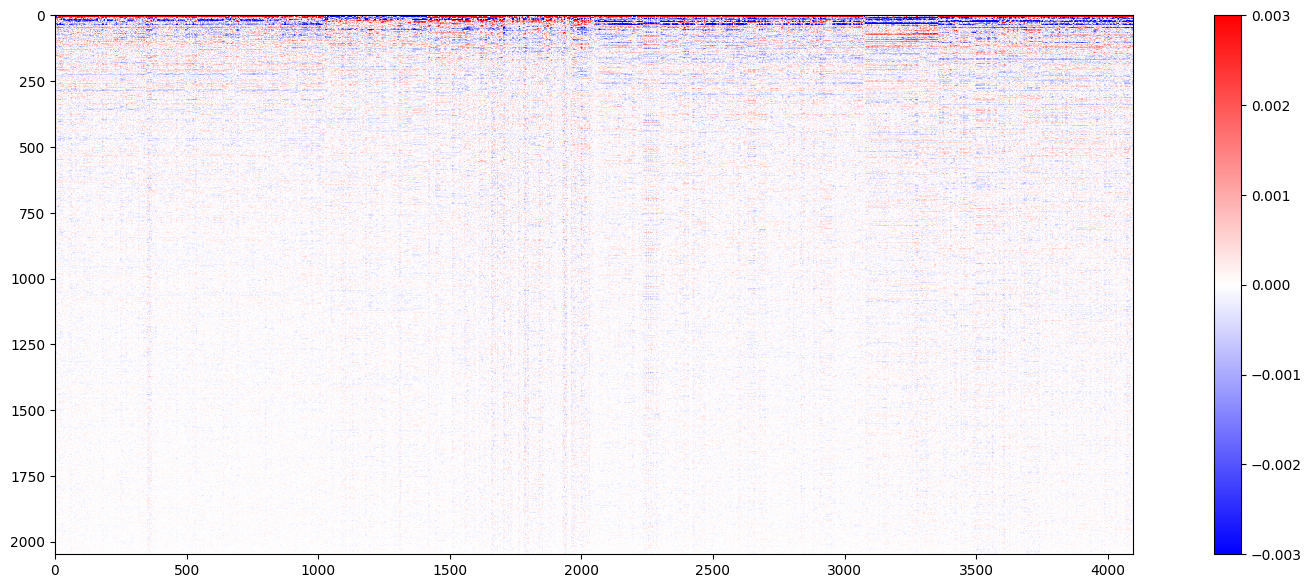

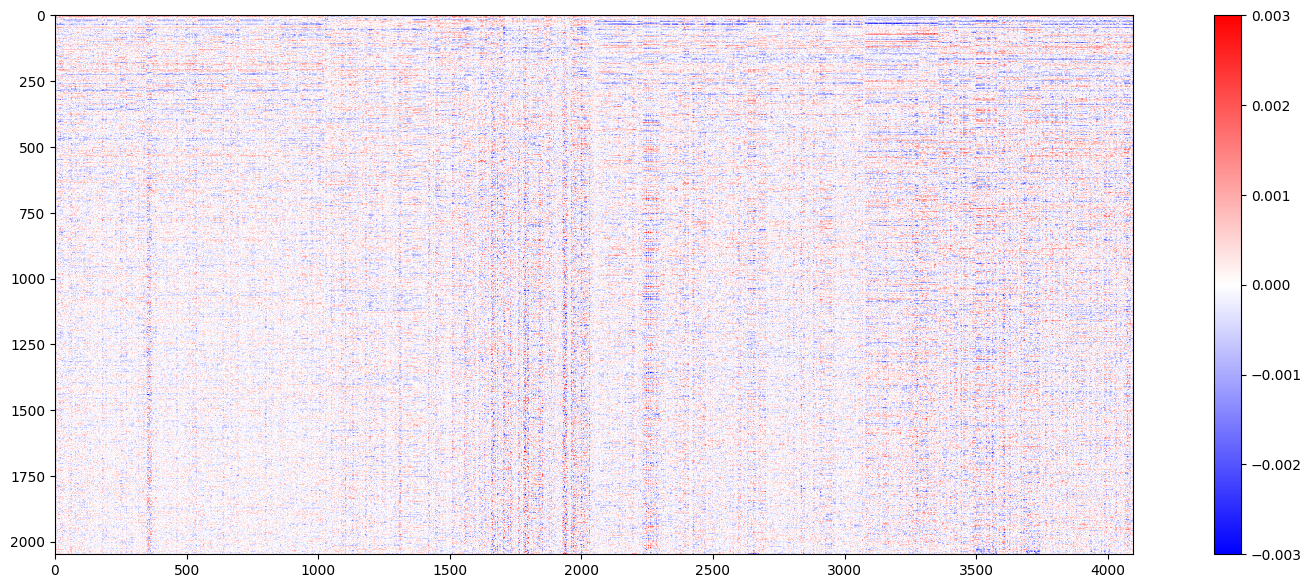

In [95]:
plt.figure(figsize=(21,7))
plt.imshow(a[4096:8192,:].cpu().detach().numpy().T/1000,vmin=-0.003,vmax=0.003,cmap='bwr')
plt.colorbar()
plt.figure(figsize=(21,7))
plt.imshow((V[4096:8192,:]).cpu().detach().numpy().T,vmin=-0.003,vmax=0.003,cmap='bwr')
plt.colorbar()
plt.figure(figsize=(21,7))
plt.imshow((S*V[4096:8192,:]).cpu().detach().numpy().T/1000,vmin=-0.003,vmax=0.003,cmap='bwr')
plt.colorbar()
plt.figure(figsize=(21,7))
plt.imshow((a[4096:8192,:]@U/S).cpu().detach().numpy().T,vmin=-0.003,vmax=0.003,cmap='bwr')
plt.colorbar()

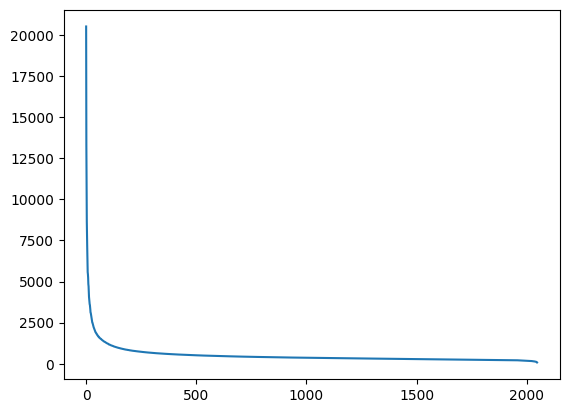

In [52]:
plt.plot(S.cpu().numpy())

In [30]:
torch.linalg.eig(cov)

torch.return_types.linalg_eig(
eigenvalues=tensor([8.6431e+08+0.j, 3.6050e+08+0.j, 2.1545e+08+0.j,  ..., 1.7392e+05+0.j,
        1.7131e+05+0.j, 1.7135e+05+0.j], device='cuda:3'),
eigenvectors=tensor([[-0.0021+0.j, -0.0012+0.j, -0.0057+0.j,  ..., -0.0174+0.j,  0.0199+0.j,
         -0.0235+0.j],
        [-0.0048+0.j,  0.0039+0.j, -0.0029+0.j,  ..., -0.0031+0.j,  0.0090+0.j,
         -0.0062+0.j],
        [-0.0007+0.j,  0.0020+0.j,  0.0071+0.j,  ...,  0.0227+0.j,  0.0244+0.j,
          0.0002+0.j],
        ...,
        [-0.0003+0.j, -0.0017+0.j,  0.0016+0.j,  ..., -0.0025+0.j, -0.0383+0.j,
         -0.0138+0.j],
        [ 0.0009+0.j,  0.0019+0.j,  0.0012+0.j,  ...,  0.0458+0.j,  0.0679+0.j,
          0.0098+0.j],
        [-0.0079+0.j,  0.0043+0.j,  0.0035+0.j,  ...,  0.0197+0.j,  0.0320+0.j,
         -0.0110+0.j]], device='cuda:3'))

In [12]:
tokenizer.decode(ID[14])

'<pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><bos># Distinguishing coloring\n\nDistinguishing coloring of a 4-hypercube graph\n\nIn graph theory, a distinguishing coloring or distinguishing labeling of a graph is an assignment of colors or labels to the vertices of the graph that destroys all of the nontrivial symmetries of the graph. The coloring does not need to be a proper coloring: adjacent vertices are allowed to be given the same color. For the colored graph, there should not exist any one-to-one mapping of the vertices to themselves that preserves both adjacency and coloring. The minimum number of colors in a distinguishing coloring is called the distinguishing number of the graph.\n\nDistinguishing colorings and distinguishing numbers were introduced by Albertson & Collins (1996), who provided the following motivating example, based on a puzzle previously formulated by Frank Rubin: "Suppose you have a ring of keys to different doors; each key only opens one door, but

In [9]:
(ID[:, 0] == 0).nonzero()[:, 0]

tensor([   14,    21,    37,  ..., 27922, 27959, 27991], device='cuda:1')

In [3]:
# Collecting data
l=[]
for file_no in tqdm(range(1,29)):
    with open(os.path.join(LOCATION,f"{file_no:04d}_id_gt.pkl"),   "rb") as f: l.append(pickle.load(f).cpu())
ID=torch.concatenate(l,dim=0).to(device)
l=[]
for file_no in tqdm(range(1,29)):
    with open(os.path.join(LOCATION,f"{file_no:04d}_id_t.pkl"),   "rb") as f: l.append(pickle.load(f).cpu())
T_ID = torch.concatenate(l, dim=0).to(device)
l=[]
for file_no in tqdm(range(1,29)):
    with open(os.path.join(LOCATION,f"{file_no:04d}_logit_s.pkl"),   "rb") as f: l.append(pickle.load(f).cpu())
SL = torch.concatenate(l, dim=0).to(device)
l=[]
for file_no in tqdm(range(1,29)):
    with open(os.path.join(LOCATION,f"{file_no:04d}_logit_t.pkl"),   "rb") as f: l.append(pickle.load(f).cpu())
TL = torch.concatenate(l, dim=0).to(device)

100%|███████████████████████████████████████████| 28/28 [00:05<00:00,  5.47it/s]


In [67]:
SNL = (torch.softmax(SL, dim=-1) + 0.0001).log()
TNL = (torch.softmax(TL, dim=-1) + 0.0001).log()

In [68]:
residuals = SNL - TNL

In [1]:
token_id

NameError: name 'token_id' is not defined

### Map_reduce

In [4]:
LOCATION = "/igli/raw_logits_v2"

In [156]:
t = !find {LOCATION} -name "*_embeddings_new"

In [184]:
len(t)*1000

2458

In [160]:
tt = [os.path.basename(x)[:4] for x in t]

In [5]:
q = quantizer_4b_torch()
w = representation_whitening_torch()
w.load_state_dict('wtorch.pth')
w.to('cuda:0')

In [7]:
file_id = 0
token_id = 235274
tid   = torch.tensor(np.fromfile(f"{LOCATION}/{file_id:04d}_id_t", dtype=np.int32).reshape(-1, 1024, 100), device=device)
gtid  = torch.tensor(np.fromfile(f"{LOCATION}/{file_id:04d}_id_gt", dtype=np.int32).reshape(1000, 1024), device=device)
ind   = torch.tensor(np.fromfile(f"{LOCATION}/{file_id:04d}_student_index_new", dtype=np.int16).reshape(-1, 2), device=device)
sprob = np.fromfile(f"{LOCATION}/{file_id:04d}_student_probs_new", dtype=np.float16).reshape(-1, 100)
semb  = np.fromfile(f"{LOCATION}/{file_id:04d}_student_embeddings_new", dtype=np.uint8).reshape(-1, 2048*4//8)

In [8]:
ind = ind.int()

In [9]:
r_teacher = (tid[ind[:,0], ind[:,1], :10] == token_id).any(axis=-1).nonzero().cpu().numpy() #rows with a good teacher prediction
r_gt = (gtid[ind[:,0], ind[:,1]] == token_id).nonzero().cpu().numpy()                       #rows where gt is token of interest
r_all = (torch.logical_or((tid[ind[:,0], ind[:,1], :10] == token_id).any(axis=-1), (gtid[ind[:,0], ind[:,1]] == token_id))).nonzero().cpu().numpy()   # rows of ind that correspond to the token of interest

In [58]:
(np.arange(10)).dtype

dtype('int64')

In [61]:
np.ones(100, dtype='bool')

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True])

In [11]:
r_teacher

array([[      6],
       [     55],
       [     72],
       ...,
       [1023029],
       [1023030],
       [1023037]])

In [13]:
logits = np.fromfile(os.path.join(LOCATION, f"{file_id:04d}_logit_t"),dtype=np.float16).reshape(-1,1024,100)

In [16]:
ind = ind.cpu().numpy()

In [20]:
len(r_all)

143472

In [19]:
logits[ind[r_teacher.reshape(-1),0], ind[r_teacher.reshape(-1),1]].shape

(143186, 100)

In [31]:
teacher_probs_good_examples.shape

torch.Size([143186, 100])

In [35]:
teacher_probs_good_examples[:, [1,2]]

tensor([[1.1603e-01, 4.2664e-02],
        [9.0981e-04, 2.9540e-04],
        [3.3522e-04, 7.4804e-05],
        ...,
        [1.2344e-02, 2.9335e-03],
        [9.1076e-04, 7.4744e-05],
        [1.0246e-02, 4.2686e-03]], device='cuda:0', dtype=torch.float16)

In [29]:
(tid[ind[r_teacher.reshape(-1),0], ind[r_teacher.reshape(-1),1]] == token_id).nonzero()[:, 1]

tensor([7, 0, 0,  ..., 9, 0, 1], device='cuda:0')

In [36]:
teacher_probs = np.zeros(len(r_all), dtype=np.float16)
teacher_probs_good_examples = torch.softmax(torch.tensor(np.fromfile(os.path.join(LOCATION, f"{file_id:04d}_logit_t"),dtype=np.float16).reshape(-1,1024,100)[ind[r_teacher.reshape(-1),0], ind[r_teacher.reshape(-1),1]], device=device), dim=-1)
teacher_probs[ind[r_teacher.reshape(-1),0]] += teacher_probs_good_examples[torch.arange(len(r_teacher)), (tid[ind[r_teacher.reshape(-1),0], ind[r_teacher.reshape(-1),1]] == token_id).nonzero()[:,1]].cpu().numpy()
teacher_probs[ind[r_gt.reshape(-1),0]] += 0.2

In [40]:
ind.shape

(1023085, 2)

In [46]:
(tid[ind[r_teacher.reshape(-1), 0], ind[r_teacher.reshape(-1),1]]==token_id).nonzero().cpu().numpy()

array([[     0,      7],
       [     1,      0],
       [     2,      0],
       ...,
       [143183,      9],
       [143184,      0],
       [143185,      1]])

In [49]:
sprob[ind[r_teacher.reshape(-1), 0], (tid[ind[r_teacher.reshape(-1), 0], ind[r_teacher.reshape(-1),1]]==token_id).nonzero()[:,1].cpu().numpy()].shape

(143186,)

In [37]:
student_probs = sprob[r_teacher.reshape(-1), (tid[ind[r_teacher.reshape(-1), 0], ind[r_teacher.reshape(-1),1]]==self.token_id).nonzero().cpu().numpy()]


OutOfMemoryError: CUDA out of memory. Tried to allocate 152.75 GiB. GPU 

In [70]:
file_id = 40
token_id = 235274 
# token_id = 235297 
tid   = np.fromfile(f"{LOCATION}/{file_id:04d}_id_t", dtype=np.int32).reshape(-1, 1024, 100)
gtid  = np.fromfile(f"{LOCATION}/{file_id:04d}_id_gt", dtype=np.int32).reshape(1000, 1024)
ind   = np.fromfile(f"{LOCATION}/{file_id:04d}_student_index_new", dtype=np.int16).reshape(-1, 2)
sprob = np.fromfile(f"{LOCATION}/{file_id:04d}_student_probs_new", dtype=np.float16).reshape(-1, 100)
semb  = np.fromfile(f"{LOCATION}/{file_id:04d}_student_embeddings_new", dtype=np.uint8).reshape(-1, 2048*4//8)
old_e = torch.tensor(np.fromfile(f"/1tb/{file_id:04d}_{token_id}_student_embeddings", dtype=np.float16).reshape(-1, 2048), device='cuda:0')
old_ind = np.fromfile(f"/1tb/{file_id:04d}_{token_id}_index", dtype=np.int16).reshape(-1, 2)

In [77]:
sprob.shape, semb.shape

((1023085, 100), (1023085, 1024))

In [71]:
e = q.load_decode(torch.tensor(semb, device='cuda:0'))

In [72]:
r = (np.logical_or((tid[ind[:,0], ind[:,1], :10] == token_id).any(axis=-1), gtid[ind[:,0], ind[:,1]] == token_id)).nonzero()

In [73]:
assert (old_ind == ind[r]).all()

In [74]:
print((((old_e - w.decode(e[r]))>5).sum() + ((old_e - w.decode(e[r]))<-5).sum())/(old_e.shape[0] * 2048))

tensor(0.0034, device='cuda:0')


In [75]:
print((old_e - w.decode(e[r])).max(), (old_e - w.decode(e[r])).min())

tensor(27.5625, device='cuda:0', dtype=torch.float16) tensor(-36.0625, device='cuda:0', dtype=torch.float16)


In [69]:
tokenizer.convert_ids_to_tokens([token_id])

['1']

In [233]:
# old_e = np.fromfile("/1tb/0000_235274_student_embeddings", dtype=np.float16).reshape(-1, 2048)
# old_ind = np.fromfile("/1tb/0000_235274_index", dtype=np.int16).reshape(-1, 2)
olde_235297 = np.fromfile("/1tb/0000_235297_student_embeddings", dtype=np.float16).reshape(-1, 2048)
oldind_235297 = np.fromfile("/1tb/0000_235297_index", dtype=np.int16).reshape(-1, 2)

In [197]:
old_ind.shape

(143472, 2)

In [165]:
sprob.shape, ind.shape, semb.shape

((1023085, 100), (1023085, 2))

In [172]:
tid[ind[:,0], ind[:,1]]

array([[     2,    185,    186, ...,   6798,   8666, 122661],
       [235303, 235349,  27321, ...,    604,   5536,   7435],
       [107844,    573,    926, ...,  68512,  99131, 111212],
       ...,
       [   476,    573,  19765, ...,   2167,   2731,   5276],
       [ 19765,   1271,  11462, ...,  39352,  58094, 199701],
       [235290,  18966, 235336, ...,   9867,  13967,  17060]], dtype=int32)

## Dataset Class

In [5]:
class MapReduceEmbeddingDataset(torch.utils.data.Dataset):
    def __init__(self, token_id, device, emb_size=2048, nfiles=100):
        
        self.token_id = token_id
        self.embedding_size = emb_size
        self.device = device
        self.limits = np.zeros(nfiles+1, dtype=np.int32)
        self.informations = self.get_indices(embedding_size=emb_size, nfiles=nfiles)
        # ---------------- NEW GET ITEM BEGIN ----------------
        self.embeddings = np.zeros((len(self), 2048), dtype=np.float16)
        # self.teacher_logits = np.zeros((len(self), 100), dtype=np.float16)
        self.teacher_probs = np.zeros(len(self), dtype=np.float16)
        self.student_probs = np.zeros(len(self), dtype=np.float16)
        self.offset = np.zeros((len(self)), dtype=np.int16)
        self.pre_read()
        # ----------------------- END ------------------------
        assert self.limits[-1] == self.informations.shape[0]
    def __len__(self):
        return self.informations.shape[0]
    def pre_read(self):
        nbytes=np.float16().nbytes
        for i, (file_id, example_id, token_pos) in tqdm(enumerate(self.informations)):
            offset = i - self.limits[file_id]
            teacher_offset = example_id * 1024 * 100 + token_pos * 100
            gt_offset      = teacher_offset // 100
            self.embeddings[i] = np.fromfile(os.path.join(LOCATION, f"{file_id:04d}_{self.token_id}_student_embeddings"), dtype=np.float16, offset=offset*2048*np.float16().nbytes,       count=self.embedding_size)

            # Rank of token_id in the teacher prediction, if any (array of length 1 or 0)
            tid = ((np.fromfile(os.path.join(LOCATION, f"{file_id:04d}_id_t"), dtype=np.int32, offset=teacher_offset*np.int32().nbytes, count=100)) == token_id).nonzero()[0]
            # Ground truth at the position we are looking at
            gt  = (np.fromfile(os.path.join(LOCATION, f"{file_id:04d}_id_gt"), dtype=np.int32, offset=gt_offset*np.int32().nbytes, count=1))[0]
            
            gt_adjustment = 0
            if (gt == self.token_id):
                gt_adjustment += 0.2
            else:
                assert len(tid) == 1
                assert tid[0] < 10
            
            # self.teacher_probs[i] = torch.softmax(torch.tensor(np.fromfile(os.path.join(LOCATION, f"{file_id:04d}_logit_t"),dtype=np.float16, offset=teacher_offset*np.float16().nbytes, count=100)), dim=-1)

            # All top_k teacher and student probs
            teacher_probs = torch.softmax(torch.tensor(np.fromfile(os.path.join(LOCATION, f"{file_id:04d}_logit_t"),dtype=np.float16, offset=teacher_offset*np.float16().nbytes, count=100)), dim=-1)
            student_probs = np.fromfile(os.path.join(LOCATION, f"{file_id:04d}_{self.token_id}_student_probs"), dtype=np.float16, offset=offset*100*np.float16().nbytes,   count=100)
            if len(tid) == 1: # token_id is in top_k
                teacher_probs[tid[0]] += gt_adjustment
                teacher_probs = (teacher_probs / teacher_probs.sum())[tid[0]]
                student_probs = student_probs[tid[0]]
            else: # token_id is just the ground truth, but not predicted as top_k by the teacher
                teacher_probs = gt_adjustment
                student_probs = 0
            self.teacher_probs[i] = teacher_probs
            self.student_probs[i] = student_probs
    def __getitem__(self, i):
        teacher_prob = torch.softmax(torch.tensor(self.teacher_logits[i]), dim=-1).numpy()
        residual_prob = teacher_prob - self.student_prob[i]
        emb = self.embeddings[i]
        offset = self.offset[i]
        return {"embedding" : emb, "residual" : residual_prob, "teacher_prob" : teacher_prob if hyperparams['weighted'] else None, "offset" : offset}
    
    def old__getitem__(self, i):
        nbytes=2
        file_id, example_id, token_pos = self.informations[i]
        offset = i - self.limits[file_id]
        teacher_offset = example_id * 1024 * 100 + token_pos * 100
        emb = np.fromfile(os.path.join(LOCATION, f"{file_id:04d}_{self.token_id}_student_embeddings"), dtype=np.float16, offset=offset*2048*nbytes,       count=self.embedding_size)
        teacher_logits= torch.tensor(np.fromfile(os.path.join(LOCATION, f"{file_id:04d}_logit_t"),        dtype=np.float16, offset=teacher_offset*nbytes, count=100                ))
        teacher_prob = torch.softmax(teacher_logits, dim=-1)
        student_prob  = np.fromfile(os.path.join(LOCATION, f"{file_id:04d}_{self.token_id}_student_probs"), dtype=np.float16, offset=offset*100*nbytes,   count=100                )
        student_prob  = torch.tensor(student_prob)
        residual_prob = teacher_prob - student_prob
        
        return {"embedding" : emb, "residual" : residual_prob, "teacher_prob" : teacher_prob if hyperparams['weighted'] else None, "offset" : offset}
    def get_indices(self, embedding_size, nfiles):
        holder = [None for _ in range(nfiles)]
        for i in range(nfiles):
            index = np.fromfile(os.path.join(LOCATION, f"{i:04d}_{token_id}_index"), dtype=np.int16).reshape(-1, 2)
            holder[i] = np.concatenate((np.repeat(i, index.shape[0]).astype(index.dtype)[..., None], index), axis=-1)
            self.limits[i+1] = index.shape[0] + self.limits[i]
        return np.concatenate(holder)
def MRcollate(data):
    embs = torch.tensor(np.concatenate([x['embedding'].reshape(1, -1) for x in data])).to(device)
    residual = torch.tensor(np.concatenate([x['residual'].reshape(1, -1) for x in  data])).to(device)
    teacher_prob = torch.tensor(np.concatenate([x['teacher_prob'].reshape(1, -1) for x in  data])).to(device) if hyperparams['weighted'] else None
    offset = torch.tensor(np.concatenate([x['offset'].reshape(-1) for x in data])).to(device)
    return {"embedding" : embs, "residual" : residual, "offset" : offset, "teacher_prob" : teacher_prob}


In [273]:
token_id = 2167
dataset = MapReduceEmbeddingDataset(token_id=token_id, device=device, nfiles=1000)

KeyboardInterrupt: 

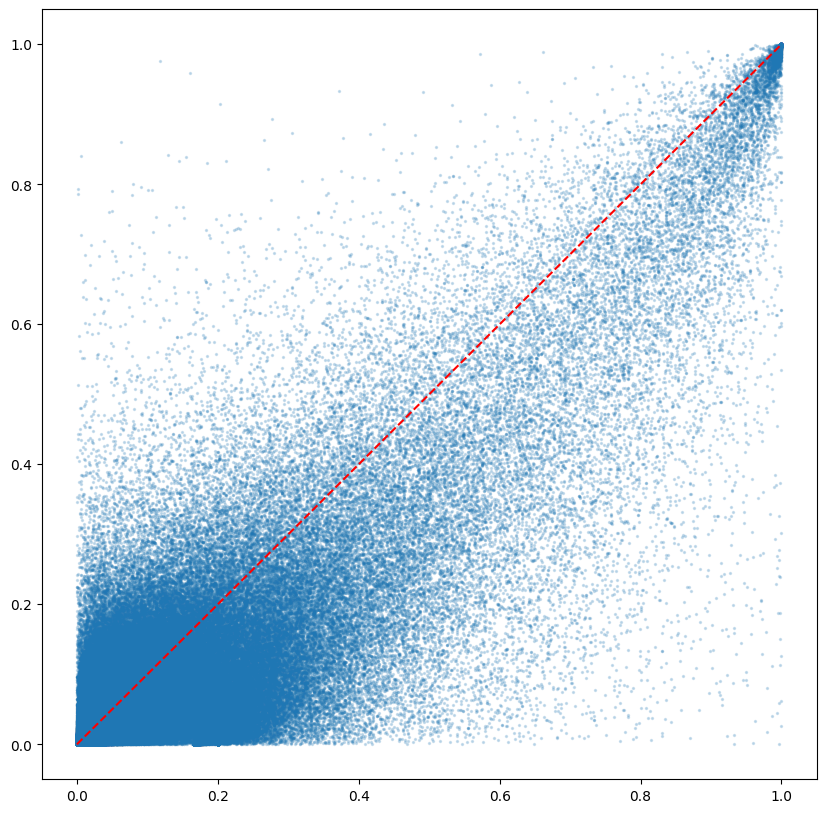

In [412]:
plt.figure(figsize=(10,10))
plt.scatter(alltprob.detach().cpu().numpy(), allsprob.detach().cpu().numpy(), s=2, alpha=0.2)
plt.plot([0,1], [0,1], '--r')

In [5]:
class EmbeddingsDataset(torch.utils.data.Dataset):
    def __init__(self, token_id, device, emb_size = 2048):
        self.token_id = token_id
        self.device = device
        self.informations = self.get_embeddings(self.token_id, embedding_size=emb_size)
        
        self.informations['embeddings']= torch.tensor(self.informations['embeddings'])
        for k, v in self.informations.items():
            self.informations[k] = v.to(self.device)
    def __len__(self):
        return self.informations['embeddings'].shape[0]
    def __getitem__(self, i):
        emb = torch.tensor(self.informations['embeddings'][i])
        example_id = self.informations['example_id'][i]
        token_pos = self.informations['positions'][i]
        return {"embedding" : emb, "example_id" : example_id, "token_pos" : token_pos}

    def read_embedding(file_num, offset, embedding_size):
        arr = np.fromfile(os.path.join(LOCATION,f"{file_num:04d}_emb_s"), dtype='float16', count=embedding_size, offset=offset)
        return arr
    
    def get_embeddings(token_id, embedding_size=2048):
        token_of_interest = token_id
        example_id, token_position = map(torch.squeeze, ((ID[:, 0][..., None] != 0) * (T_ID == token_of_interest).any(dim=-1)).nonzero().split(1, dim=1))
        ranks = (T_ID[example_id, token_position] == token_of_interest).nonzero()[:, 1]
        filenumber = example_id // 1000 + 1
        offsets = token_position * embedding_size
        embeddings = [self.read_embedding(file_no, offset, embedding_size) for (file_no, offset) in zip(filenumber, offsets)]
        embeddings = np.stack(embeddings)
        matrix_info = {
            'embeddings': embeddings,
            'example_id': example_id,
            'positions' : token_position,
            'ranks'     : ranks,
        }
        return matrix_info
    
def get_targets(model, embeddings):
    logits = model(embeddings)
    probs = torch.softmax(logits, dim=-1)
    normed_logits = probs.log() + 0.0001
    return normed_logits, probs

def collate(data):
    embs = torch.concatenate([x['embedding'].reshape(0) for x in data])
    ids = torch.concatenate([x['example_id'].reshape(-1) for x in  data])
    pos = torch.concatenate([x['token_pos'].reshape(-1) for x in data])
    return {"embedding" : embs, "example_id" : ids, "token_pos" : pos}


# Training the embedding layer

### Class definitions

In [7]:
class linearlayer(torch.nn.Module):
    def __init__(self, token_id, device, embedding_size = 2048):
        super(linearlayer, self).__init__()
        self.embedding_size = embedding_size
        self.token_of_interest = token_id
        self.linear1 =torch.nn.Linear(self.embedding_size, 1, device=device,dtype=torch.float32,bias=False)
        
        with torch.no_grad():
            self.linear1.weight.data=(self.linear1.weight*0)
    
        self.device=device
    
    def forward(self, input_embs, res_prob, teacher_prob):
        input_embs = input_embs.to(torch.float32)
        res_prob = res_prob.to(torch.float32)
        teacher_prob = teacher_prob.to(torch.float32)
        y = self.linear1(input_embs)
        loss = torch.abs(res_prob - y)
        loss = loss * teacher_prob
        return y, loss

class linearlayer_withbias(torch.nn.Module):
    def __init__(self, token_id, device, embedding_size = 2048):
        super(linearlayer_withbias, self).__init__()
        self.embedding_size = embedding_size
        self.token_of_interest = token_id
        self.linear1 =torch.nn.Linear(self.embedding_size, 1, device=device,dtype=torch.float32,bias=True)
        
        with torch.no_grad():
            self.linear1.weight.data=(self.linear1.weight*0)
    
        self.device=device
    
    def forward(self, input_embs, res_prob, teacher_prob):        
        input_embs = input_embs.to(torch.float32)
        res_prob = res_prob.to(torch.float32)
        teacher_prob = teacher_prob.to(torch.float32)
        y = self.linear1(input_embs)
        loss = torch.abs(res_prob - y)
        loss = loss * teacher_prob
        return y, loss

In [6]:
#Multi
class multi_embedding(torch.nn.Module):
    def __init__(self, token_id, device, embedding_size = 2048, number_of_clusters = 2):
        super(multi_embedding, self).__init__()
        self.number_of_clusters=number_of_clusters
        self.embedding_size = embedding_size
        self.normalization_factor = torch.sqrt(torch.tensor(self.embedding_size).to(device))
        self.token_of_interest = token_id
        self.linear1 =torch.nn.Linear(self.embedding_size, self.number_of_clusters, device=device,dtype=torch.float32,bias=True)
        # self.linear2 =torch.nn.Linear(self.number_of_clusters, 1, device=device,dtype=torch.float32,bias=False)
        # with torch.no_grad():
        #     self.linear1.weight.data=(self.linear1.weight*0.01)

        self.device=device
        self.relu=torch.nn.ReLU()
    
    def forward(self, input_embs, student_prob, teacher_prob, weight, percentage=100):
        input_embs = input_embs.to(torch.float32)
        student_prob = student_prob.to(torch.float32)
        teacher_prob = teacher_prob.to(torch.float32)
        print(input_embs, input_embs.shape)
        scores = self.linear1(input_embs)
        scores/=self.normalization_factor
        ps=self.relu(scores)
        print(ps)
        split = int(ps.shape[1] * percentage / 100)
        y = ps[:, :split].sum(dim=-1) - ps[:, split:].sum(dim=-1)
        # y = self.linear2(ps).squeeze()
        # y=torch.maximum(y,-student_prob) # This is not needed anymore i think(?)
        print(y)
        y+=student_prob
        y=torch.clip(y,0,configuration['residual_scaler'])
        print(y)
        # L1
        l1_loss = torch.abs ((teacher_prob - y))
        l1_loss = l1_loss * weight
        # L2
        l2_loss = (teacher_prob - y)**2
        l2_loss = l2_loss * weight
        # KL
        kl_loss = torch.abs(teacher_prob * ((y+1e-9).log() - (teacher_prob+1e-9).log()))
        #default all-zero-l1
        l1_default_zero = torch.abs((teacher_prob - student_prob)) * weight
        #default zero l2
        l2_default_zero = ((teacher_prob - student_prob) ** 2) * weight
        losses = {
            'l1' : l1_loss,
            'l2' : l2_loss,
            'kl' : kl_loss,
            'l1_0':l1_default_zero,
            'l2_0':l2_default_zero,
        }
        
        return y, losses

class multi_embedding_withbias(torch.nn.Module):
    def __init__(self, token_id, device, embedding_size = 2048, number_of_clusters = 2):
        super(multi_embedding_withbias, self).__init__()
        self.number_of_clusters=number_of_clusters
        self.embedding_size = embedding_size
        self.normalization_factor = torch.sqrt(torch.tensor(self.embedding_size).to(device))
        self.token_of_interest = token_id
        self.linear1 =torch.nn.Linear(self.embedding_size, self.number_of_clusters, device=device,dtype=torch.float32,bias=True)
        # self.linear2 =torch.nn.Linear(self.number_of_clusters, 1, device=device,dtype=torch.float32,bias=False)
        # with torch.no_grad():
        #     self.linear1.weight.data=(self.linear1.weight*0.01)

        self.device=device
        self.relu=torch.nn.ReLU()
    
    def forward(self, input_embs, res_prob, teacher_prob):
        input_embs = input_embs.to(torch.float32)
        res_prob = res_prob.to(torch.float32)
        teacher_prob = teacher_prob.to(torch.float32)
        # print('input_embs',input_embs.shape)
        scores = self.linear1(input_embs)
        scores/=self.normalization_factor
        #print('scores',scores.shape)
        # ps=torch.softmax(scores,dim=-1)
        ps=self.relu(scores)
        # print(ps)
        #print('ps',ps.shape)
        # y =self.linear2(ps)/50
        # y =(ps[:,0:self.number_of_clusters//2].sum(dim=-1,keepdims=True)-ps[:,self.number_of_clusters//2:self.number_of_clusters].sum(dim=-1,keepdims=True))
        y = ps
        # print('y',y.shape)
        # loss = torch.abs ((res_prob- y))
        loss = ((res_prob- y)**2)
        loss = loss * teacher_prob
        return y, loss


In [40]:
# Deep
class deepnet(torch.nn.Module):
    def __init__(self, token_id, device, embedding_size = 2048):
        super(deepnet, self).__init__()
        self.embedding_size = embedding_size
        self.token_of_interest = token_id
        self.linear1 =torch.nn.Linear(self.embedding_size, 100, device=device,dtype=torch.float32,bias=True)
        self.linear2 =torch.nn.Linear(100, 1, device=device, dtype=torch.float32, bias=True)
        self.relu =torch.nn.ReLU()
        self.dropout = torch.nn.Dropout(p=0.2)

        with torch.no_grad():
            self.linear1.weight.data=(self.linear1.weight*0)
            self.linear2.weight.data=(self.linear2.weight*0)
    
        self.device=device
    
    def forward(self, input_embs, res_prob, teacher_prob):
        input_embs = input_embs.to(torch.float32)
        res_prob = res_prob.to(torch.float32)
        teacher_prob = teacher_prob.to(torch.float32)
        y = self.linear1(input_embs)
        y = self.relu(y)
        y = self.dropout(y)
        y = self.linear2(y)
        loss = torch.abs(res_prob - y)
        loss = loss * teacher_prob
        return y, loss


### Old Data

In [72]:
import copy

token_of_interest = 2167 #1142 #digit_ids[6] # ['▁theory']
train_dataset = EmbeddingsDataset(token_of_interest, device = 'cuda:0', emb_size=2048)
test_dataset = copy.deepcopy(train_dataset)
my_filter = train_dataset.informations['example_id'] < 25000
for k in train_dataset.informations.keys():
    train_dataset.informations[k] = train_dataset.informations[k][my_filter]
    test_dataset.informations[k] = test_dataset.informations[k][~my_filter]

In [73]:
tokenizer = AutoTokenizer.from_pretrained('google/gemma-7b')
digit_ids = tokenizer('1 2 3 4 5 6 7 8 9 0')['input_ids'][1::2]

In [40]:
token_of_interest = 1758 #digit_ids[6] # ['▁theory']
digit_train_dataset = EmbeddingsDataset(digit_ids[0], device = 'cuda:0', emb_size=2048)
import copy
digittest_dataset = copy.deepcopy(digit_train_dataset)
my_filter = (digit_train_dataset.informations['example_id'] < 25000).cpu()


OutOfMemoryError: CUDA out of memory. Tried to allocate 15.09 GiB. GPU 

In [ ]:
for k in digit_train_dataset.informations.keys():
    digit_train_dataset.informations[k] = digit_train_dataset.informations[k].cpu()[my_filter]
    digittest_dataset.informations[k] = digittest_dataset.informations[k].cpu()[~my_filter]
torch.cuda.empty_cache()
torch.cuda.synchronize()
for k in digit_train_dataset.informations.keys():
    digit_train_dataset.informations[k] = digit_train_dataset.informations[k].to('cuda:0')
    digittest_dataset.informations[k] = digittest_dataset.informations[k].to('cuda:0')


In [75]:
# del digit_train_dataset
# del digittest_dataset
# del train_dataset
# del test_dataset
# del dataset
torch.cuda.empty_cache()
torch.cuda.synchronize()

In [76]:
teacher_probs = torch.softmax(TL, dim=-1).to('cuda:1')
student_probs = torch.softmax(SL, dim=-1).to('cuda:1')
residual_probs = teacher_probs - student_probs

In [78]:
## Dataset shuffling
dataset = train_dataset
torch.manual_seed(0)
num_pts = len(dataset)
permutation = torch.randperm(num_pts)
for k,v in dataset.informations.items():
    dataset.informations[k] = v[permutation]

In [79]:
test_dataset = test_dataset

In [80]:
residual_probs = residual_probs.to('cuda:0')
teacher_probs = teacher_probs.to('cuda:0')

In [81]:
example_ids.device,token_pos.device,embeddings.device, residual_prob.device ,embeddings.device

NameError: name 'example_ids' is not defined

In [82]:
torch.cuda.empty_cache()
torch.cuda.synchronize()

In [83]:
model

NameError: name 'model' is not defined

In [84]:
hyperparams

NameError: name 'hyperparams' is not defined

In [86]:
train_dataset.__dict__

{'token_id': 2167,
 'device': 'cuda:0',
 'informations': {'embeddings': tensor([[ 0.3276, -2.0781,  0.2654,  ..., -1.6338,  0.5571,  0.3442],
          [ 0.0353,  0.6880,  0.6299,  ..., -0.0572,  0.6357,  0.5723],
          [ 1.7100,  0.7183, -0.2123,  ...,  1.0791, -0.0721, -0.3298],
          ...,
          [-1.0117,  0.5005,  1.0244,  ..., -0.0660,  0.8535,  1.0342],
          [ 0.6621, -0.1763,  0.3445,  ..., -0.6313, -0.4324, -0.2091],
          [ 0.7085, -5.2539,  1.3037,  ..., -0.5581,  0.2849, -0.9019]],
         device='cuda:0', dtype=torch.float16),
  'example_id': tensor([ 7736,   180, 18549,  ..., 10691,  2989, 23453], device='cuda:0'),
  'positions': tensor([ 47, 746, 482,  ..., 888, 250, 457], device='cuda:0'),
  'ranks': tensor([1, 3, 3,  ..., 2, 2, 5], device='cuda:0')}}

In [87]:
train_dataset.informations['embeddings'].shape

torch.Size([144297, 2048])

In [82]:
torch.arange(2048).repeat(2).shape

torch.Size([4096])

In [15]:
train_dataset.informations['embeddings'].shape

torch.Size([156619, 2048])

In [43]:
torch.arange(2048).repeat(2)

tensor([   0,    1,    2,  ..., 2045, 2046, 2047])

In [90]:
tokenizer.decode(train_dataset.token_id), tokenizer.decode(test_dataset.token_id)

(' different', ' different')

In [89]:
tokenizer.decode(train_dataset_set.token_id)

NameError: name 'train_dataset_set' is not defined

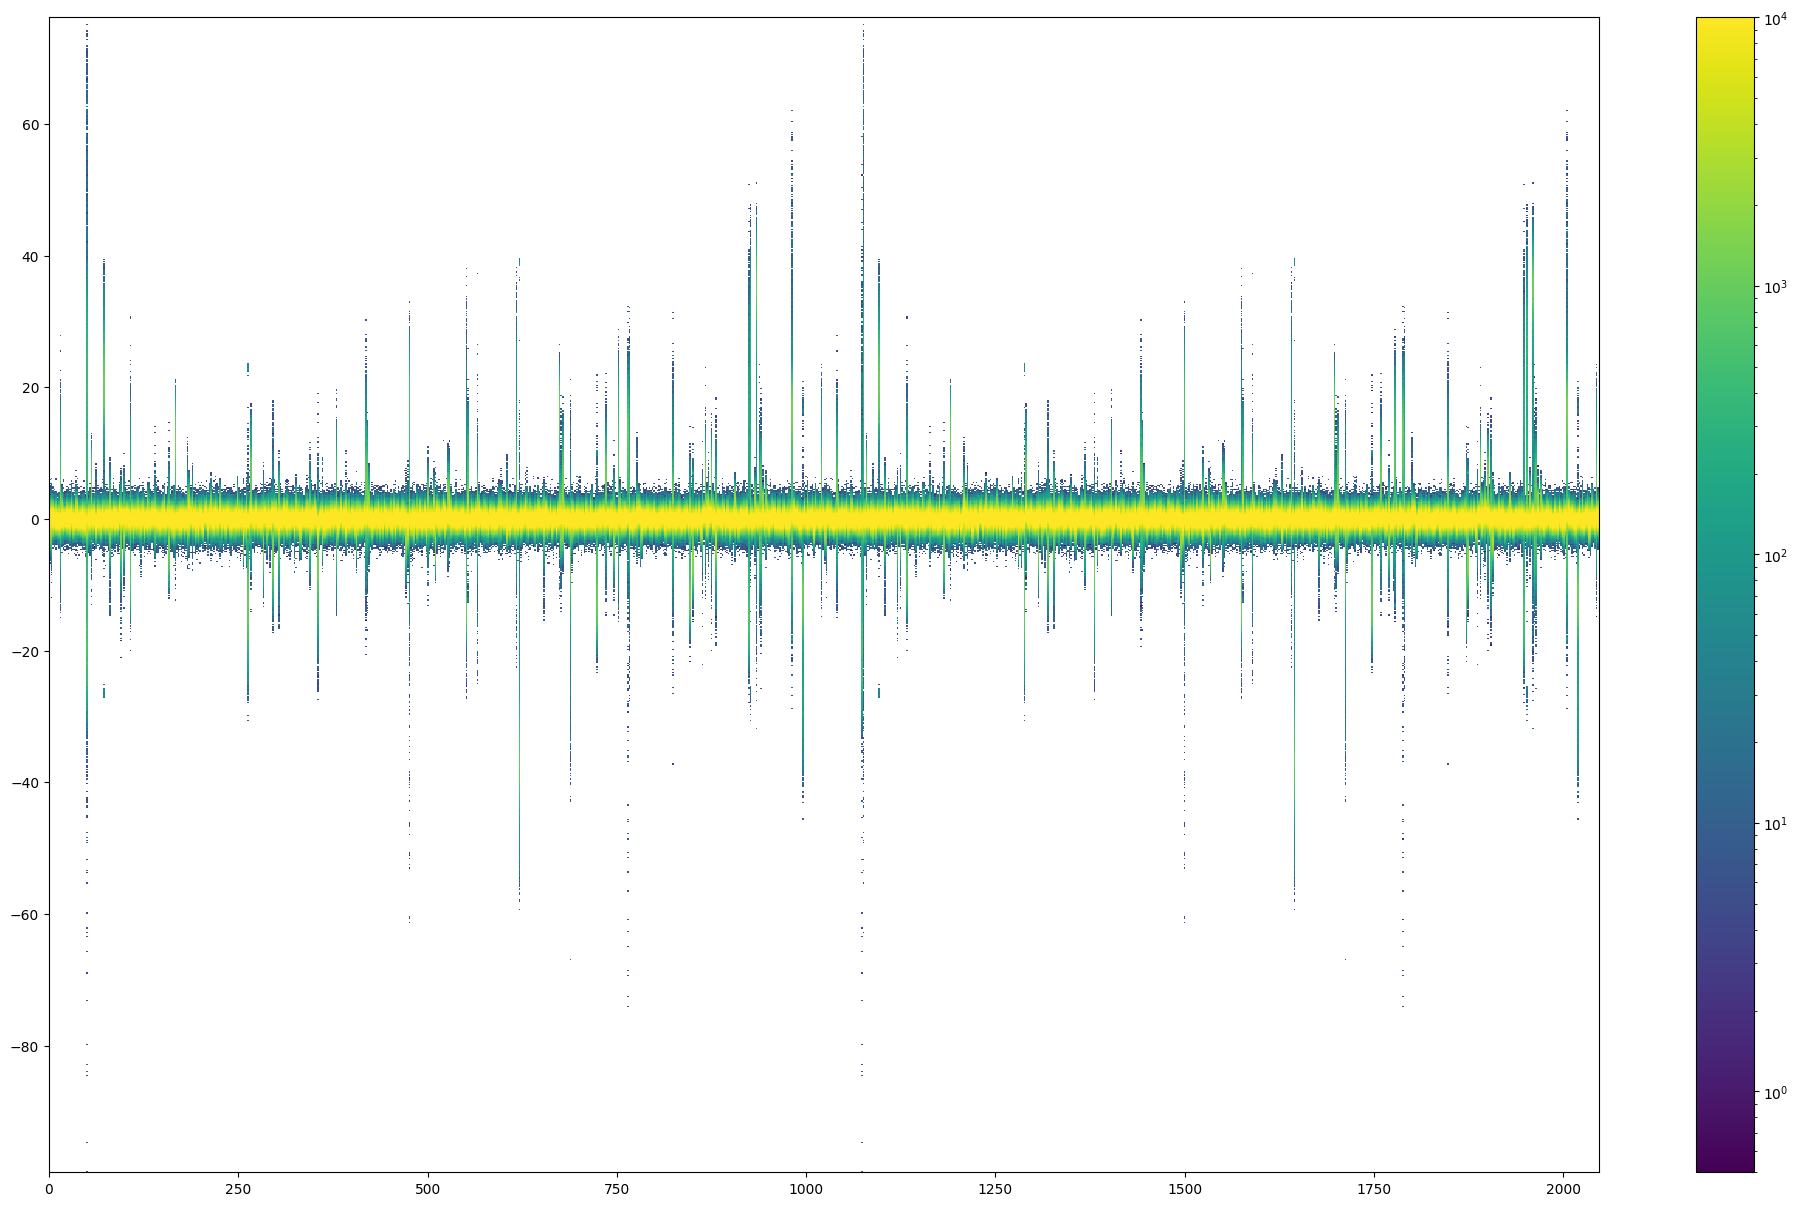

In [91]:
from matplotlib.colors import LogNorm
plt.figure(figsize=(25,15))
plt.hist2d(torch.arange(2048).repeat(train_dataset.informations['embeddings'].shape[0]).cpu(), train_dataset.informations['embeddings'].reshape(-1).cpu(), bins=1000,norm=LogNorm(vmin=0.5, vmax=10000))
plt.colorbar()

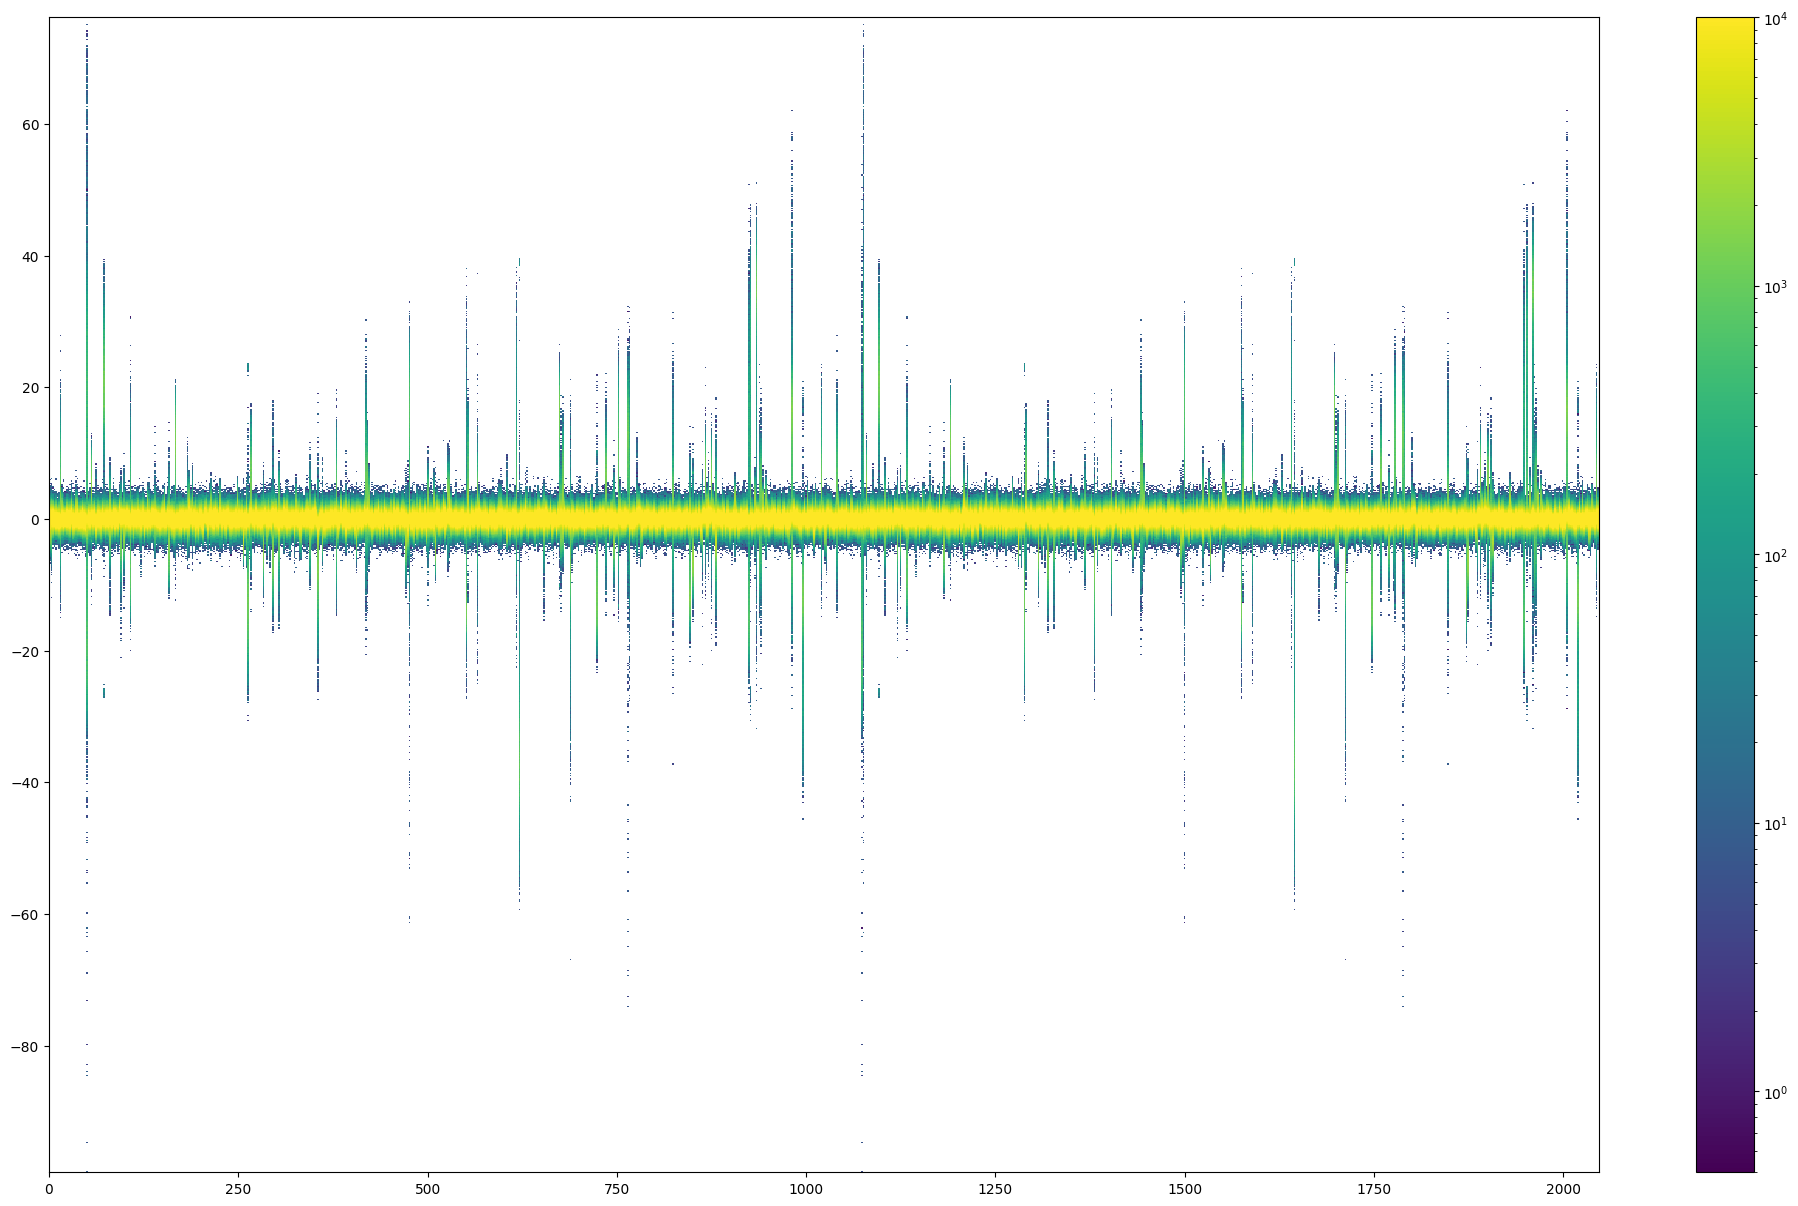

In [59]:
from matplotlib.colors import LogNorm
plt.figure(figsize=(25,15))
plt.hist2d(torch.arange(2048).repeat(train_dataset_set.informations['embeddings'].shape[0]).cpu(), train_dataset_set.informations['embeddings'].reshape(-1).cpu(), bins=1000,norm=LogNorm(vmin=0.5, vmax=10000))
plt.colorbar()

<ErrorbarContainer object of 3 artists>

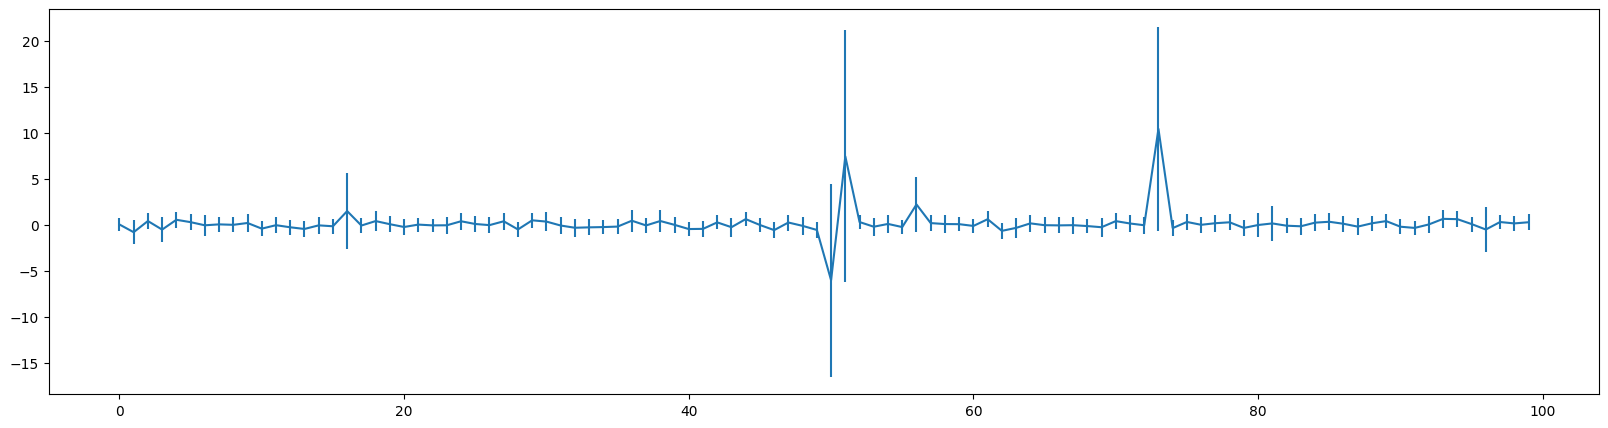

In [92]:
plt.figure(figsize=(20,5))
plt.errorbar(x=np.arange(100),y= train_dataset.informations['embeddings'].mean(dim=0).cpu().numpy()[0:100],yerr= train_dataset.informations['embeddings'].std(dim=0).cpu().numpy()[0:100])

In [93]:
train_dataset_set.informations['embeddings'].shape

NameError: name 'train_dataset_set' is not defined

In [94]:
train_dataset.informations['embeddings'].shape

torch.Size([144297, 2048])

<ErrorbarContainer object of 3 artists>

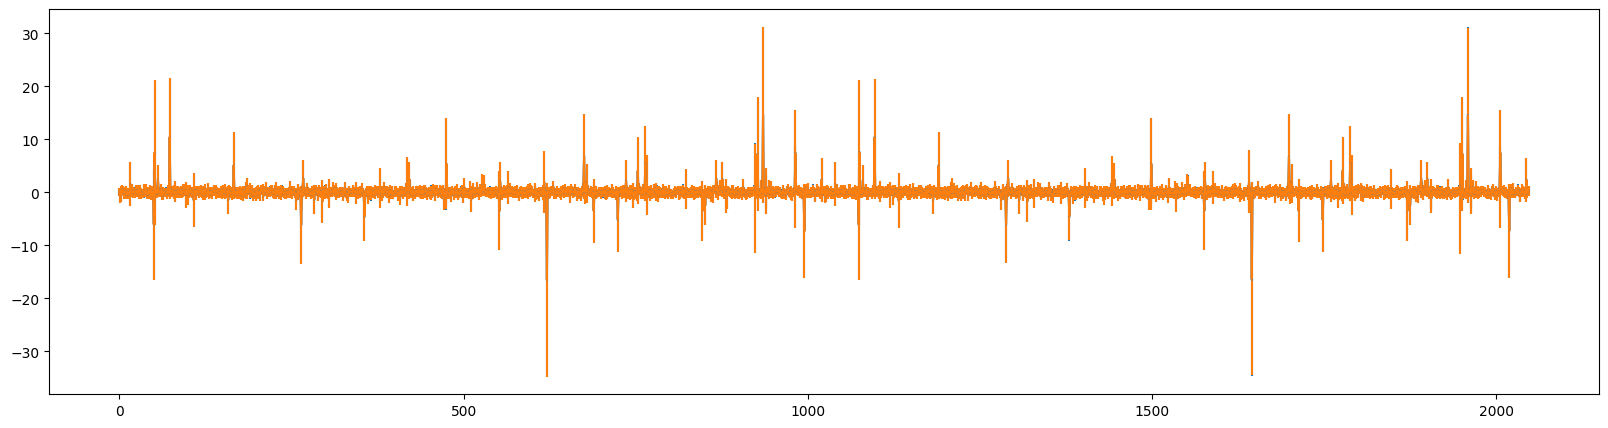

In [61]:
plt.figure(figsize=(20,5))
plt.errorbar(x=np.arange(2048),y= train_dataset_set.informations['embeddings'].mean(dim=0).cpu().numpy()[0:2048],yerr= train_dataset_set.informations['embeddings'].std(dim=0).cpu().numpy()[0:2048])
plt.errorbar(x=np.arange(2048),y= train_dataset.informations['embeddings'].mean(dim=0).cpu().numpy()[0:2048],yerr= train_dataset.informations['embeddings'].std(dim=0).cpu().numpy()[0:2048])

<ErrorbarContainer object of 3 artists>

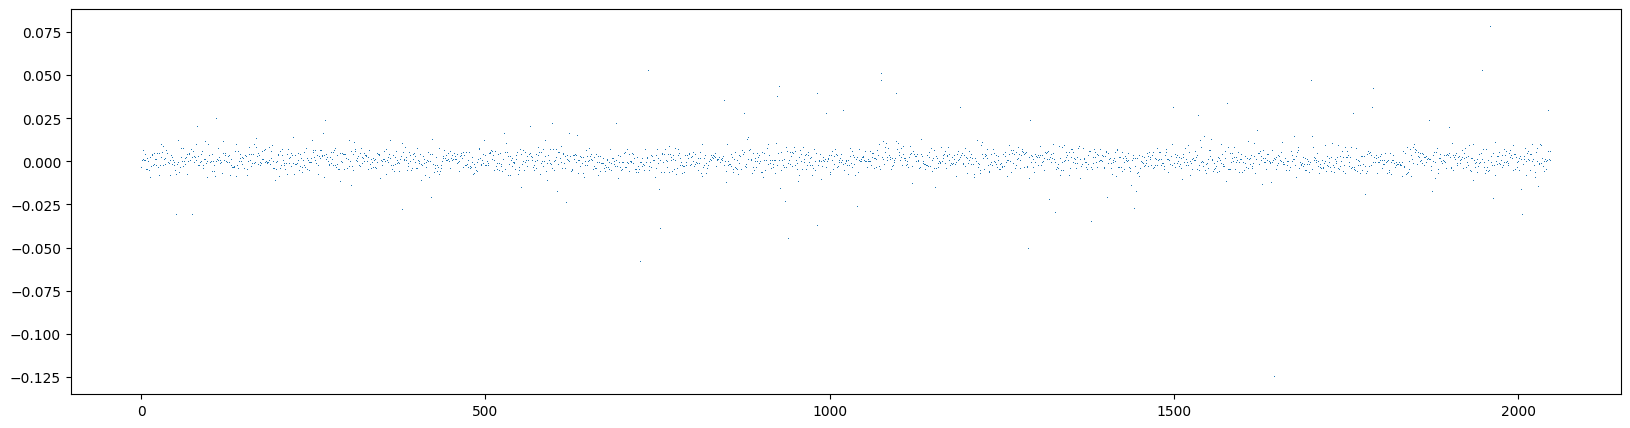

In [70]:
plt.figure(figsize=(20,5))
plt.errorbar(x=np.arange(2048),y= train_dataset_set.informations['embeddings'].mean(dim=0).cpu().numpy()[0:2048]-train_dataset.informations['embeddings'].mean(dim=0).cpu().numpy()[0:2048], fmt=',')#,yerr= train_dataset_set.informations['embeddings'].std(dim=0).cpu().numpy()[0:2048] + train_dataset.informations['embeddings'].std(dim=0).cpu().numpy()[0:2048], fmt=',')
# plt.errorbar(x=np.arange(2048),y= train_dataset.informations['embeddings'].mean(dim=0).cpu().numpy()[0:2048],yerr= train_dataset.informations['embeddings'].std(dim=0).cpu().numpy()[0:2048])

In [47]:
a=train_dataset_set.informations['embeddings'].mean(dim=0)
b=train_dataset    .informations['embeddings'].mean(dim=0)

In [48]:
a.norm()

tensor(51.1562, device='cuda:0', dtype=torch.float16)

In [49]:
b.norm()

tensor(51.0312, device='cuda:0', dtype=torch.float16)

In [51]:
tokenizer('city')

{'input_ids': [2, 8918], 'attention_mask': [1, 1]}

In [50]:
(a-b).norm()

tensor(0.6172, device='cuda:0', dtype=torch.float16)

In [45]:
(train_dataset_set.informations['embeddings'].mean(dim=0).cpu().numpy()-train_dataset.informations['embeddings'].mean(dim=0).cpu().numpy())

AttributeError: 'numpy.ndarray' object has no attribute 'norm'

In [ ]:
(train_dataset_set.informations['embeddings'].mean(dim=0).cpu().numpy()-train_dataset.informations['embeddings'].mean(dim=0).cpu().numpy()).norm()

### Train Loop

### other

In [375]:
token_id1 = 2167
dataset1 = MapReduceEmbeddingDataset(token_id=token_id, device=device, nfiles=1000)

3170166it [53:29, 987.61it/s] 


KeyboardInterrupt: 

In [46]:
token_id = 2167
dataset = MapReduceEmbeddingDataset(token_id=token_id, device=device, nfiles=100)

661621it [02:31, 4380.37it/s]


In [47]:
segment = int(10**6 * 1.6)

oldsegment = 660000
segment = oldsegment

allemb = torch.tensor(dataset.embeddings[:segment])#.to(device)
alltprob = torch.tensor(dataset.teacher_probs[:segment])#.to(device)
allsprob = torch.tensor(dataset.student_probs[:segment])#.to(device)
allres = alltprob - allsprob
allemb_ = allemb - allemb.mean(dim=0, keepdims=True)

In [48]:
dataset.teacher_probs[:segment].tofile('teacher_probs')
dataset.student_probs[:segment].tofile('student_probs')

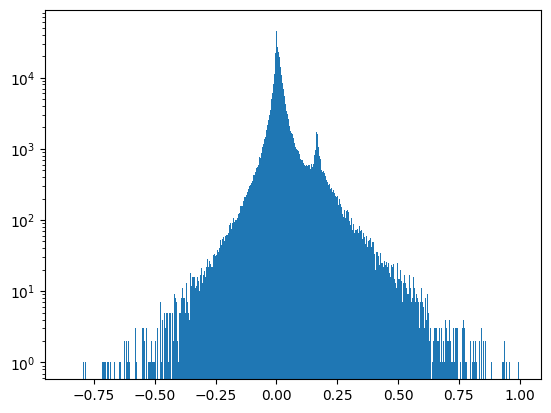

In [15]:
plt.hist(allres, bins=1000);
plt.yscale('log')


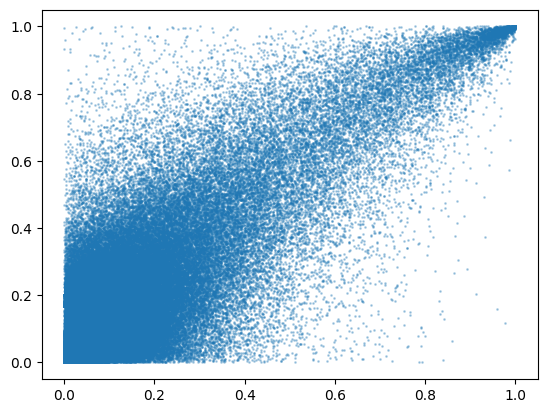

In [16]:
plt.scatter(allsprob.cpu(),alltprob.cpu(),s=1, alpha=0.3);
# plt.xlim((0,0.1))
# plt.ylim((0,0.1))


In [160]:
# Sanity checks
torch.manual_seed(0)
indices = torch.randperm(allemb_.size(0))
allemb__ = allemb_[indices]
batchsize = 1000
allemb_batched = allemb__[:size].reshape(-1, batchsize, 2048)
alltprob_batched = alltprob[:size].reshape(-1, batchsize)
allres_batched = allres[:size].reshape(-1, batchsize)

train_size = int(allemb_batched.size(0) * 0.8)

train_emb, test_emb = allemb_batched[:train_size].to(device), allemb_batched[train_size:].to(device)
train_tprob, test_tprob = alltprob_batched[:train_size].to(device), alltprob_batched[train_size:].to(device)
train_res, test_res = allres_batched[:train_size].to(device), allres_batched[train_size:].to(device)

epochs = 1000
BASELINE = [0]
cluster_size = [4,16,64, 128]
lr = 0.0001
oo = 'adam'
# oo = 'sgd'
loss = 'kl'
# loss = 'l1'
# loss = 'l2'
residual_scaler = 10
for lr in [0.0001]:
    for loss in ['l1', 'l2']:
    # for loss in ['l2']:
        for cc in cluster_size:
            torch.manual_seed(0)
            model = multi_embedding(token_id, device, number_of_clusters=cc)
            optimizer = optim.SGD(model.parameters(), lr = lr) if oo == 'sgd' else optim.Adam(model.parameters(), lr=lr, betas=(0.9, 0.99))
            location = f'sanitycheck/single_prob/debug/original/residual/{oo}/{loss}/scalar={residual_scaler}_epochs={epochs}_sizexbatch={size}x{batchsize}_lr={lr}_shifted_{cc}'
            writer = SummaryWriter(location)
            for epoch in range(epochs):
                # Train loss
                trainloss = 0
                for embeddings, teacher_probs, residual_prob in zip(train_emb, train_tprob, train_res):
                    label = residual_prob
                    tp = teacher_probs
                    output, losses = model(embeddings, label*residual_scaler, tp)
                    # Batched loss
                    lval = losses[loss].mean()
                    optimizer.zero_grad()
                    lval.backward()
                    optimizer.step()
                    trainloss += losses[loss].sum().item()
                writer.add_scalar(f'{loss.upper()}/Average Train Loss', trainloss/(train_size * batchsize), 48*(epoch +1)) 
                
                # Test Loss
                with torch.no_grad():
                    testloss = 0
                    for embeddings, teacher_probs, residual_prob in zip(test_emb, test_tprob, test_res):
                        label = residual_prob
                        tp = teacher_probs
                        output, losses = model(embeddings, label*residual_scaler, tp)
                        testloss += losses[loss].sum().item()
                    writer.add_scalar(f'{loss.upper()}/Average Test Loss', testloss/(size - train_size * batchsize), 48*(epoch+1))
                    writer.add_scalar(f'{loss.upper()}/Overfitting indicator: Difference', testloss/(size - train_size * batchsize) - trainloss/(train_size * batchsize), 48*(epoch +1))
                    writer.add_scalar(f'{loss.upper()}/Overfitting indicator: Ratio', (testloss/(size - train_size * batchsize)) / (trainloss/(train_size * batchsize)), 48*(epoch +1))


KeyboardInterrupt: 

### Main

In [7]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans
import torch
import os

class quantizer_8b:
    def fit(self, a):
        kmenas = KMeans(n_clusters=2**7)
        kmeans.fit(np.abs(a).reshape(-1,1))
        self.centers = kmeans.cluster_centers_.reshape(-1)
        self.centers = np.sort(self.centers)
        self.thresholds=(self.centers[1:]+self.centers[:-1])/2
        self.centers=np.concatenate([self.centers,-self.centers])
    def quantize(self,a):
        is_negative=np.sign(a)<0
        a2=np.abs(a)
        index=np.ones(a2.shape,dtype=np.int8)*(2**6-1)

        right_size = a2 > self.thresholds[index]
        
class quantizer_4b:
    
    def fit(self,a):
        kmeans = KMeans(n_clusters=8)
        kmeans.fit( np.abs(a).reshape(-1,1))
        self.centers=kmeans.cluster_centers_.reshape(-1)
        self.centers=np.sort(self.centers)
        self.thresholds=(self.centers[1:]+self.centers[:-1])/2
        self.centers=np.concatenate([self.centers,-self.centers])
        
    def quantize(self,a):
        is_negative=np.sign(a)<0
        a2=np.abs(a)
        index=np.ones(a2.shape,dtype=np.int8)*3

        right_side=a2>self.thresholds[index]
        index=index-2+right_side*4
        
        right_side=a2>self.thresholds[index]
        index=index-1+right_side*2

        right_side=a2>self.thresholds[index]
        index=index+right_side
        
        index=index+8*is_negative
        return index
    
    def decode(self,index):
        return self.centers[index]
    
    def quantize_compress(self,a):
        ind=self.quantize(a)
        comp=ind[:,0::2]*16+ind[:,1::2]
        return comp.astype(np.uint8)

    def load_decode(self,data):
        ind=np.zeros((data.shape[0],data.shape[1]*2),dtype=np.uint8)
        ind[:,0::2]=data//16
        ind[:,1::2]=data% 16
        return self.decode(ind)
    
    def save_model(self, path):
        self.centers[:8].tofile(os.path.join(path, '4b_positive_centers'))
    def load_model(self, path, size):
        self.centers = np.fromfile(os.path.join(path, '4b_positive_centers'), dtype=np.float32) if size == 32 else np.fromfile(os.path.join(path, '4b_positive_centers'), dtype=np.float64)
        assert self.centers.shape[0] == 8
        self.thresholds=(self.centers[1:]+self.centers[:-1])/2
        self.centers=np.concatenate([self.centers,-self.centers])
        
class quantizer_2b:
    
    def fit(self,a):
        kmeans = KMeans(n_clusters=2)
        kmeans.fit( np.abs(a).reshape(-1,1))
        self.centers=kmeans.cluster_centers_.reshape(-1)
        self.centers=np.sort(self.centers)
        self.thresholds=(self.centers[1:]+self.centers[:-1])/2
        self.centers=np.concatenate([self.centers,-self.centers])
        
    def quantize(self,a):
        is_negative=np.sign(a)<0
        a2=np.abs(a)
        index=np.ones(a2.shape,dtype=np.int8)*0

        right_side=a2>self.thresholds[index]
        index=index+right_side
        
        index=index+2*is_negative
        return index
    
    def decode(self,index):
        return self.centers[index]
    
    def quantize_compress(self,a):
        ind=self.quantize(a)
        comp=ind[:,0::4]*64+ind[:,1::4]*16+ind[:,2::4]*4+ind[:,3::4]*1
        return comp.astype(np.uint8)

    def load_decode(self,data):
        ind=np.zeros((data.shape[0],data.shape[1]*4),dtype=np.uint8)
        ind[:,0::4]=(data//64)%4
        ind[:,1::4]=(data//16)%4
        ind[:,2::4]=(data// 4)%4
        ind[:,3::4]=(data// 1)%4
        return self.decode(ind)
    def save_model(self, path):
        self.centers[:2].tofile(os.path.join(path, '2b_positive_centers'))
    def load_model(self, path, size):
        self.centers = np.fromfile(os.path.join(path, '2b_positive_centers'), dtype=np.float32) if size == 32 else np.fromfile(os.path.join(path, '2b_positive_centers'), dtype=np.float64)
        assert self.centers.shape[0] == 2
        self.thresholds=(self.centers[1:]+self.centers[:-1])/2
        self.centers=np.concatenate([self.centers,-self.centers])
class quantizer_1b:
    
    def fit(self,a):
        meana=np.mean(np.abs(a))
        self.centers=np.array([meana,-meana])
        
    def quantize(self,a):
        is_negative=np.sign(a)<0
        return (is_negative).astype(np.uint8)
    
    def decode(self,index):
        return self.centers[index]
    
    def quantize_compress(self,a):
        ind=self.quantize(a)
        comp=ind[:,0::8]*128+ind[:,1::8]* 64+ind[:,2::8]* 32+ind[:,3::8]* 16+ind[:,4::8]*  8+ind[:,5::8]*  4+ind[:,6::8]*  2+ind[:,7::8]*  1
        return comp.astype(np.uint8)

    def load_decode(self,data):
        ind=np.zeros((data.shape[0],data.shape[1]*8),dtype=np.uint8)
        ind[:,0::8]=(data//128)%2
        ind[:,1::8]=(data//64)%2
        ind[:,2::8]=(data//32)%2
        ind[:,3::8]=(data//16)%2
        ind[:,4::8]=(data// 8)%2
        ind[:,5::8]=(data// 4)%2
        ind[:,6::8]=(data// 2)%2
        ind[:,7::8]=(data// 1)%2
        return self.decode(ind)
    def save_model(self, path):
        self.centers[0:1].tofile(os.path.join(path, '1b_positive_centers'))
    def load_model(self, path, size):
        self.centers = np.fromfile(os.path.join(path, '1b_positive_centers'), dtype=np.float32) if size == 32 else np.fromfile(os.path.join(path, '1b_positive_centers'), dtype=np.float64)
        assert self.centers.shape[0] == 1
        self.centers=np.concatenate([self.centers,-self.centers])    
class quantizer_mixed:
    
    def fit(self,a, proportions=None):
        if proportions is None:
            self.proportion_4b=1/8
            self.proportion_2b=4/8
            self.proportion_1b=3/8
        else:
            self.proportion_4b, self.proportion_2b, self.proportion_1b = proportions
            
        self.count_4b=np.round(self.proportion_4b*a.shape[1]).astype(np.int32)
        self.count_2b=np.round(self.proportion_2b*a.shape[1]).astype(np.int32)
        self.count_1b=np.round(self.proportion_1b*a.shape[1]).astype(np.int32)
        self.q4=quantizer_4b()
        self.q2=quantizer_2b()
        self.q1=quantizer_1b()
        
        self.q4.fit(a[:,              : self.count_4b])
        self.q2.fit(a[:, self.count_4b:-self.count_1b])
        self.q1.fit(a[:,-self.count_1b:              ])
                
    def quantize(self,a):
        a4=self.q4.quantize(a[:,              : self.count_4b])
        a2=self.q2.quantize(a[:, self.count_4b:-self.count_1b])
        a1=self.q1.quantize(a[:,-self.count_1b:              ])      
        return np.concatenate([a4,a2,a1],axis=1)
    
    def decode(self,index):
        index4=self.q4.decode(index[:,              : self.count_4b])
        index2=self.q2.decode(index[:, self.count_4b:-self.count_1b])
        index1=self.q1.decode(index[:,-self.count_1b:              ])      
        return np.concatenate([index4,index2,index1],axis=1)

    def quantize_compress(self,a):
        comp4=self.q4.quantize_compress(a[:,              : self.count_4b])
        comp2=self.q2.quantize_compress(a[:, self.count_4b:-self.count_1b])
        comp1=self.q1.quantize_compress(a[:,-self.count_1b:              ])      
        return np.concatenate([comp4,comp2,comp1],axis=1)

    def load_decode(self,comp):
        comp4=comp[:, 0                 : self.count_4b*4//8]
        comp2=comp[:, self.count_4b*4//8:-self.count_1b*1//8]
        comp1=comp[:,-self.count_1b*1//8:                   ]
        a4=self.q4.load_decode(comp4)
        a2=self.q2.load_decode(comp2)
        a1=self.q1.load_decode(comp1)
        return np.concatenate([a4,a2,a1],axis=1)
        
    def save_model(self, path):
        if not os.path.exists(path):
            print(f"Improper path {path}")
            return
        save_dir = os.path.join(path, f"{int(self.count_4b)}_{int(self.count_2b)}_{int(self.count_1b)}")
        os.makedirs(save_dir, exist_ok=True)
        self.q4.save_model(save_dir)
        self.q2.save_model(save_dir)
        self.q1.save_model(save_dir)
    def load_model(self, path, size):
        self.q4=quantizer_4b()
        self.q2=quantizer_2b()
        self.q1=quantizer_1b()
        self.q4.load_model(path, size)
        self.q2.load_model(path, size)
        self.q1.load_model(path, size)
        self.count_4b, self.count_2b, self.count_1b = map(int, os.path.basename(path).split('_'))
        
class representation_whitening:
    
    def fit(self,a):
        self.mn=a.mean(axis=0)
        
        # low memory covariance calculation
        cov=np.zeros((a.shape[1],a.shape[1]))
        for i in range(0,a.shape[0],10000):
            aslice=torch.tensor(a[i:i+10000,:]-self.mn).to('cuda:1').to(torch.float32)
            cov+=( aslice.T@aslice).cpu().numpy()/a.shape[0]
            
        s2,self.q=np.linalg.eigh(cov)
        self.s=np.sqrt(s2)
        
        if self.s[0]<self.s[-1]:
            self.s=np.flip(self.s)
            self.q=self.q[:,::-1]+0 # add 0 to avoid negative stride error
       
    def encode(self,a):
        qgpu=torch.tensor(self.q   ).to('cuda:1').to(torch.float32)
        agpu=torch.tensor(a-self.mn).to('cuda:1').to(torch.float32)
        return (agpu@qgpu).cpu().numpy()/self.s
    
    def decode(self,e):
        qgpu=torch.tensor(self.q   ).to('cuda:1').to(torch.float32)
        egpu=torch.tensor(self.s*e ).to('cuda:1').to(torch.float32)
        return ( egpu@qgpu.T).cpu().numpy()+self.mn
    
    def rescale(self,e):
        return self.s*e


In [4]:
# centers = torch.tensor(np.fromfile('centers', dtype=np.float64))

# thresholds = torch.tensor(np.fromfile('thresholds', dtype=np.float64))

allemb_ = torch.tensor(np.fromfile('allemb_', dtype = np.float16)).reshape(-1,2048)

# allemb_quant = torch.tensor(np.fromfile('allemb_quant', dtype=np.float16).reshape(-1, 2048))

In [5]:
allemb_ = allemb_.to(device)

In [113]:
model1 = multi_embedding(1, device, number_of_clusters=64)
model2 = multi_embedding(1, device, number_of_clusters=64)
model3 = multi_embedding(1, device, number_of_clusters=8)
model4 = multi_embedding(1, device, number_of_clusters=8)

In [122]:
combined_weight = torch.concatenate((model1.linear1.weight,model2.linear1.weight,model3.linear1.weight,model4.linear1.weight), dim=0)
combined_bias   = torch.concatenate((model1.linear1.bias,  model2.linear1.bias,  model3.linear1.bias,  model4.linear1.bias), dim=0)

In [142]:
model1.linear1.weight.shape

torch.Size([64, 2048])

In [123]:
combined_out = torch.nn.functional.relu(torch.nn.functional.linear(allemb_[:5].float(), combined_weight, combined_bias))

In [124]:
combined_out /= torch.sqrt(torch.tensor(2048))

In [117]:
student_probs_temp = torch.tensor(sp__[:20].reshape(5,4), device=device)

In [118]:
teacher_probs_temp = torch.tensor(tp__[:20].reshape(5,4), device=device)

In [126]:
big_1 = combined_out[:,:64*2].reshape(5,2,64).sum(dim=-1) 
small_1 = combined_out[:, 64*2:].reshape(5,2,8).sum(dim=-1)
combined_1 = torch.concatenate((big_1, small_1), dim=1)
combined_2 = combined_1 + student_probs_temp
combined_3 = torch.clip(combined_2,0, 10)


In [137]:
combined_3

tensor([[0.4986, 0.1783, 0.0357, 0.0342],
        [0.5244, 0.3067, 0.0272, 0.0124],
        [0.5174, 0.3156, 0.0925, 0.0297],
        [0.4917, 0.2063, 0.0813, 0.1022],
        [0.3172, 0.2237, 0.0725, 0.2833]], device='cuda:0',
       grad_fn=<ClampBackward1>)

In [54]:
configuration = {"residual_scaler" : 10}

In [147]:
(torch.arange(5)<3).nonzero()

tensor([[0],
        [1],
        [2]])

In [148]:
torch.concatenate((*(torch.arange(5)<3).nonzero(), *(torch.arange(10)<7).nonzero()), dim=0)

tensor([0, 1, 2, 0, 1, 2, 3, 4, 5, 6])

In [133]:
combined_2[:, 0]

tensor([0.4986, 0.5244, 0.5174, 0.4917, 0.3172], device='cuda:0',
       grad_fn=<SelectBackward0>)

In [144]:
torch.concatenate(list(map(lambda x : x.unsqueeze(1), (o1[0], o2[0], o3[0], o4[0]))), dim=1)

tensor([[0.4986, 0.1783, 0.0357, 0.0342],
        [0.5244, 0.3067, 0.0272, 0.0124],
        [0.5174, 0.3156, 0.0925, 0.0297],
        [0.4917, 0.2063, 0.0813, 0.1022],
        [0.3172, 0.2237, 0.0725, 0.2833]], device='cuda:0',
       grad_fn=<CatBackward0>)

In [134]:
o1 = model1(allemb_[:5], student_probs_temp[:, 0], teacher_probs_temp[:, 0], weight=torch.ones(5,1).to(device))
o2 = model2(allemb_[:5], student_probs_temp[:, 1], teacher_probs_temp[:, 1], weight=torch.ones(5,1).to(device))
o3 = model3(allemb_[:5], student_probs_temp[:, 2], teacher_probs_temp[:, 2], weight=torch.ones(5,1).to(device))
o4 = model4(allemb_[:5], student_probs_temp[:, 3], teacher_probs_temp[:, 3], weight=torch.ones(5,1).to(device))

tensor([[-0.1202, -0.3184, -0.5405,  ..., -0.1752, -0.0242,  0.0815],
        [-0.6079, -1.0098,  0.4644,  ...,  0.0988,  0.2803, -0.8750],
        [-1.0137, -0.7549,  0.0919,  ...,  0.1180,  1.1309,  0.5874],
        [-0.2167, -1.2266,  0.2013,  ...,  0.0405,  0.5815,  0.4683],
        [ 0.7173, -0.5254,  0.3359,  ...,  0.0698,  0.8374,  0.3672]],
       device='cuda:0') torch.Size([5, 2048])
tensor([[0.0000, 0.0061, 0.0192, 0.0143, 0.0000, 0.0224, 0.0135, 0.0223, 0.0021,
         0.0000, 0.0000, 0.0031, 0.0000, 0.0180, 0.0085, 0.0163, 0.0030, 0.0000,
         0.0171, 0.0010, 0.0000, 0.0000, 0.0000, 0.0000, 0.0249, 0.0000, 0.0000,
         0.0088, 0.0266, 0.0000, 0.0000, 0.0094, 0.0000, 0.0000, 0.0000, 0.0161,
         0.0000, 0.0000, 0.0087, 0.0142, 0.0011, 0.0000, 0.0011, 0.0000, 0.0000,
         0.0000, 0.0146, 0.0080, 0.0000, 0.0048, 0.0000, 0.0000, 0.0034, 0.0019,
         0.0218, 0.0000, 0.0000, 0.0000, 0.0000, 0.0138, 0.0087, 0.0038, 0.0066,
         0.0000],
        [0.0000, 0

In [84]:
o1[0]

tensor([0.4323, 0.3968, 0.4145, 0.5159, 0.2593], device='cuda:0',
       grad_fn=<ClampBackward1>)

In [85]:
combined_3

tensor([[2.6019e-01, 7.4946e-03, 1.7285e-04, 4.2191e-03],
        [1.1212e-01, 6.6223e-02, 1.2903e-03, 8.0526e-05],
        [7.7985e-02, 1.2436e-02, 1.1909e-02, 3.9520e-03],
        [8.4812e-01, 1.0048e-02, 1.8123e-01, 5.8441e-02],
        [7.9770e-02, 2.8006e-01, 1.1856e-02, 2.5000e-01]], device='cuda:0',
       grad_fn=<ClampBackward1>)

In [11]:
W_torch = representation_whitening_torch()
W_torch.fit(allemb_)
W_torch.save_state_dict('wtorch.pth')
allemb_w = W_torch.encode(allemb_)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████| 66/66 [00:00<00:00, 1066.00it/s]


In [12]:
q4_torch = quantizer_4b_torch()
q2_torch = quantizer_2b_torch()
q1_torch = quantizer_1b_torch()

quant4torch = W_torch.rescale(q4_torch.load_decode(q4_torch.quantize_compress(allemb_w)))
quant2torch = W_torch.rescale(q2_torch.load_decode(q2_torch.quantize_compress(allemb_w)))
quant1torch = W_torch.rescale(q1_torch.load_decode(q1_torch.quantize_compress(allemb_w)))

In [13]:
quant4torch.dtype, quant2torch.dtype, quant1torch.dtype, quant4torch.shape, quant2torch.shape, quant1torch.shape

(torch.float16,
 torch.float16,
 torch.float16,
 torch.Size([660000, 2048]),
 torch.Size([660000, 2048]),
 torch.Size([660000, 2048]))

In [28]:
configuration = {
    'epochs' : 20,
    'batchsize' : 1000,
    'num_clusters' : [8],
    'lr' : 0.0001,
    'optimizer' : 'adamw',
    'loss' : 'l1',
    'weight_decay' : 1,
    'train_log_step' : 10,
    'test_log_step' : 100,
    'residual_scaler' : 10,
    'percentage' : 100,
    'target' : 'teacher', # Either teacher or residual,
    'note': ''
}

def zca1(x):
    s, u = torch.linalg.eigh(x.T @ x)
    scale = torch.sqrt(len(x) / s)
    return (u * scale) @ u.T

class Trainer():
    def __init__(self, token_id, device):
        self.token_id = token_id
        self.device  = device
    def build_dataset(self, nfiles):
        self.dataset = MapReduceEmbeddingDataset(token_id=token_id, device=self.device, nfiles=nfiles)
    def set_dataset(self, dataset):
        self.dataset = dataset
    def train(self, configuration, data=None):
        collected = torch.zeros((0)).to(self.device)
        batchsize = configuration['batchsize']
        epochs = configuration['epochs']
        cluster_size = configuration['num_clusters']
        lr = configuration['lr']
        oo = configuration['optimizer']
        token_id = self.token_id
        if data is None:
            size = (len(self.dataset) // batchsize) * batchsize
            allemb = torch.tensor(self.dataset.embeddings)#.to(device)
            alltprob = torch.tensor(self.dataset.teacher_probs)#.to(device)
            allsprob = torch.tensor(self.dataset.student_probs)#.to(device)
            allemb_ = allemb - allemb.mean(dim=0, keepdims=True)
            allemb_quant = allemb_ / allemb_.std(dim=0, keepdims=True)
            Quantizer.fit(allemb_quant)
            allemb_quant = Quantizer.decode(Quantizer.quantize(allemb_quant))
        else:
            size = (len(data[0]) // batchsize) * batchsize
            allemb_ = (data[0][:size])
            allemb_quant = (data[1][:size])
            alltprob = torch.tensor(data[2][:size])
            allsprob = torch.tensor(data[3][:size])
        # allres = alltprob - allsprob
        torch.manual_seed(0)
        indices = torch.randperm(allemb_.size(0))
        allemb__ = allemb_[indices]
        allemb__quant = allemb_quant[indices]
        alltprob = alltprob[indices]
        allsprob = allsprob[indices]
        # allres = allres[indices]
        
        allemb_batched = allemb__[:size].reshape(-1, batchsize, 2048)
        allemb_quant_batched = allemb__quant.reshape(-1, batchsize, 2048) 
        alltprob_batched = alltprob[:size].reshape(-1, batchsize)
        allsprob_batched = allsprob[:size].reshape(-1, batchsize)
        # allres_batched = allres[:size].reshape(-1, batchsize)
        
        device = self.device
        train_size = int(allemb_batched.size(0) * 0.8)
        train_emb, test_emb, train_emb_quant, test_emb_quant = allemb_batched[:train_size].to(device), allemb_batched[train_size:].to(device), allemb_quant_batched[:train_size].to(device), allemb_quant_batched[train_size:].to(device)
        train_tprob, test_tprob = alltprob_batched[:train_size].to(device), alltprob_batched[train_size:].to(device)
        # train_res, test_res = allres_batched[:train_size].to(device), allres_batched[train_size:].to(device)
        train_sprob, test_sprob = allsprob_batched[:train_size].to(device), allsprob_batched[train_size:].to(device)
        
        parallel_states = []
        residual_scaler = configuration['residual_scaler']
        for loss in [configuration['loss']]:
            for cc in cluster_size:
                torch.manual_seed(0)
                for iii in range(4):
                    model = multi_embedding(token_id, device, number_of_clusters=cc)
                    optimizer = optim.SGD(model.parameters(), lr = lr, weight_decay=configuration['weight_decay']) if oo == 'sgd' else optim.AdamW(model.parameters(), lr=lr, betas=(0.9, 0.99), weight_decay=configuration['weight_decay'])
                    # location = f'reduce_step/{oo}/{loss}/{configuration["target"]}_probs/{configuration["note"]}_case={iii}_ps={configuration["percentage"]}_residual_scaler={configuration["residual_scaler"]}_epochs={epochs}_sizexbatch={size}x{batchsize}_lr={lr}_weightdecay={optimizer.state_dict()["param_groups"][0]["weight_decay"]}_{cc}'
                    # location = f'bits_experiments/{configuration["note"]}'
                    # location = f'bits_experiments_torch/{configuration["note"]}'
                    # location = f'target_experiment/{configuration["note"]}'
                    location = f'combined_model/{configuration["note"]}'
                    writer = SummaryWriter(location)
                    parallel_states.append({
                        'model' : model,
                        'optimizer' : optimizer,
                        'writer' : writer,
                        'loss' : loss,
                        'train_loss' : 0,
                        'test_loss'  : 0
                    })
        step_count = 0
        log_step = configuration['train_log_step']
        validation_step = configuration['test_log_step']
        for epoch in range(epochs):
            # Train loss
            for embeddings_normal, embeddings_quant, teacher_probs, student_probs in tqdm(zip(test_emb, test_emb_quant, test_tprob, test_sprob)):
                step_count += 1
                # label = residual_prob
                # label = teacher_probs if configuration['target'] == 'teacher' else residual_prob
                weights = torch.ones_like(teacher_probs)
                for iii, state in enumerate(parallel_states):
                    iii = iii % 4
                    if iii != 3:
                        continue
                    # Test Loss
                    if step_count % validation_step == 1:
                        with torch.no_grad():
                            model.eval()
                            default_loss = 0
                            prediction = torch.zeros(0, device=model.device)
                            for embeddings_normal, embeddings_quant, teacher_probs, student_probs in zip(test_emb, test_emb_quant, test_tprob, test_sprob):
                                embeddings = embeddings_normal if iii % 2 == 0 else embeddings_quant
                                # label = teacher_probs if configuration['target'] == 'teacher' else residual_prob
                                weights = torch.ones_like(teacher_probs)
                                output, losses = model(embeddings, student_probs * configuration['residual_scaler'], teacher_probs * configuration['residual_scaler'], weights, configuration['percentage'])
                                prediction = torch.concatenate((prediction, output), dim=0)
                                state['test_loss'] += losses[loss].sum().item()
                                default_loss += losses[f"{loss}_0"].sum().item()
                            # plt.figure()
                            # plt.title("Teacher Case")
                            # plt.scatter((prediction.cpu()/configuration['residual_scaler']), test_tprob.reshape(-1).cpu(), s=1, alpha=0.2)
                            # plt.plot([0,1],[0,1], '--r')
                            # writer.add_figure(f'Distributions/{configuration["percentage"]}%, Scalar={configuration["residual_scaler"]}', plt.gcf(), step_count-1)
                            # plt.figure()
                            # plt.title("Residuals")
                            # plt.scatter(((prediction-test_sprob.reshape(-1))/configuration['residual_scaler']).cpu(), (test_tprob-student_probs).reshape(-1).cpu(), s=1, alpha=0.2)
                            # writer.add_figure(f'Distributions/Residual {configuration["percentage"]}%, Scalar={configuration["residual_scaler"]}', plt.gcf(), step_count-1)
                            writer.add_scalar(f'{loss.upper()}/Average Test Loss', state['test_loss']/(test_emb.size(0)*test_emb.size(1)), step_count-1)
                            writer.add_scalar(f'{loss.upper()}/Overfitting indicator: Ratio', (state['test_loss'] / default_loss), step_count-1)
                            # writer.add_scalar(f'{loss.upper()}/Overfitting indicator: Difference', state['test_loss'] - state['train_loss']/(log_step * batchsize), step_count-1)
                            # writer.add_scalar(f'{loss.upper()}/Overfitting indicator: Ratio', state['test_loss'] / ( state['train_loss']/(log_step * batchsize)), step_count-1)
                            state['test_loss'] = 0
                            if epoch == epochs-1:
                                collected = torch.concatenate((collected, output), dim=0)
                    embeddings = embeddings_normal if iii//2==0 else embeddings_quant
                    model, optimizer, writer, loss = state['model'], state['optimizer'], state['writer'], state['loss']
                    model.train()
                    output, losses = model(embeddings, student_probs * configuration['residual_scaler'], teacher_probs * configuration['residual_scaler'], weights, configuration['percentage'])
                    # Batched loss
                    lval = losses[loss].mean()
                    optimizer.zero_grad()
                    lval.backward()
                    optimizer.step()
                    state['train_loss'] += losses[loss].sum().item()
        
                    if step_count % log_step == 0:
                        writer.add_scalar(f'{loss.upper()}/Average Train Loss', state['train_loss']/(log_step * batchsize), step_count)
                        state['train_loss'] = 0
        
        # return collected, parallel_states, (test_emb, test_emb_quant, test_tprob, test_res)
        

In [29]:
trainer = Trainer(2167, 'cuda:2')

In [16]:
configuration['epochs'] = 20

In [24]:
tp__ = np.fromfile('teacher_probs', dtype=np.float16)
sp__ = np.fromfile('student_probs', dtype=np.float16)

In [18]:
quant4torch = quant4torch.cpu()
quant2torch = quant2torch.cpu()
quant1torch = quant1torch.cpu()

In [14]:
W_torch.s = W_torch.s.to('cuda:2')

In [19]:
torch.cuda.empty_cache()

In [20]:
tests = [
    [0, 2048, 0, 0]
    # [0,1536,512,0],
    # [0,1536,0,512],
    # [0,1024,1024,0],
    # [0,512,1536,0],
    # [0,1024,512,512],
    # [0,256,1792,0],
    # [0,512,1024,512],
    # [0,512,768,768],
    # [0,1024,0,1024],
    # [0,512,512,1024],
    # [0,64,1984,0],
    # [0,256,896,896],
    # [0,256,768,1024],
    # [0,512,0,1536],
    # [0,256,0,1792],
    # [0,0,2048,0],
    # [0,64,0,1984],
    # [0,0,0,2048],
    # [64,256,512,1216 ]
]

In [39]:
for cut0, cut1, cut2, cut3 in tests:
    # mix = torch.zeros_like(allemb_)
    # mix[:,:cut0] = allemb_[:,:cut0]
    # mix[:,cut0:cut0+cut1] = quant4[:,cut0:cut0+cut1]
    # mix[:,cut0+cut1:cut0+cut1+cut2] = quant2[:,cut0+cut1:cut0+cut1+cut2]
    # mix[:,cut0+cut1+cut2:cut0+cut1+cut2+cut3] = quant1[:,cut0+cut1+cut2:cut0+cut1+cut2+cut3]
    # data = (allemb_, mix[:660000], tp__, sp__)
    data = (allemb_, quant4torch[:660000], tp__, sp__)
    torch.cuda.empty_cache()
    configuration['percentage'] = 100
    configuration['epochs'] = 50
    configuration['target'] = 'residual'
    configuration['residual_scaler'] = 1
    configuration['num_clusters'] = [16]
    configuration['lr'] = 0.0002
    configuration['loss'] = 'l1'
    configuration['weight_decay'] = 1
    configuration['note'] = f'{configuration["percentage"]}_percent_residual={configuration["residual_scaler"]}'
    trainer.train(configuration, data=data)
    torch.cuda.empty_cache()

132it [00:11, 11.82it/s]
132it [00:05, 23.63it/s]
132it [00:05, 23.36it/s]
132it [00:10, 12.25it/s]
132it [00:05, 23.59it/s]
132it [00:05, 23.43it/s]
132it [00:11, 11.97it/s]
132it [00:05, 23.66it/s]
132it [00:05, 23.44it/s]
132it [00:11, 11.84it/s]
132it [00:05, 23.78it/s]
132it [00:05, 23.48it/s]
132it [00:11, 11.84it/s]
132it [00:05, 23.91it/s]
132it [00:05, 23.75it/s]
132it [00:11, 11.94it/s]
132it [00:05, 23.32it/s]
132it [00:05, 24.30it/s]
132it [00:11, 11.99it/s]
132it [00:05, 23.83it/s]
132it [00:05, 23.63it/s]
132it [00:11, 11.94it/s]
132it [00:05, 23.47it/s]
132it [00:05, 24.12it/s]
132it [00:05, 23.31it/s]
132it [00:11, 11.95it/s]
132it [00:05, 23.83it/s]
132it [00:05, 23.41it/s]
132it [00:11, 11.97it/s]
132it [00:05, 23.19it/s]
132it [00:05, 24.12it/s]
132it [00:11, 11.74it/s]
132it [00:05, 24.09it/s]
132it [00:05, 23.73it/s]
132it [00:11, 11.82it/s]
132it [00:05, 23.34it/s]
132it [00:05, 23.42it/s]
132it [00:10, 12.04it/s]
132it [00:05, 23.27it/s]
132it [00:05, 24.30it/s]


528it [00:01, 492.12it/s]
528it [00:01, 510.76it/s]
528it [00:01, 521.21it/s]
528it [00:01, 491.34it/s]
528it [00:00, 532.46it/s]
528it [00:01, 525.83it/s]
528it [00:01, 526.75it/s]
528it [00:01, 499.40it/s]
528it [00:00, 534.10it/s]
528it [00:00, 531.05it/s]
528it [00:01, 498.94it/s]
528it [00:00, 528.03it/s]
528it [00:01, 526.28it/s]
528it [00:00, 530.53it/s]
528it [00:01, 500.14it/s]
528it [00:00, 534.86it/s]
528it [00:01, 522.93it/s]
528it [00:01, 493.48it/s]
528it [00:00, 529.45it/s]
528it [00:01, 524.93it/s]
528it [00:01, 498.29it/s]
528it [00:00, 528.50it/s]
528it [00:00, 528.50it/s]
528it [00:01, 494.39it/s]
528it [00:01, 524.21it/s]
528it [00:01, 524.49it/s]
528it [00:01, 525.01it/s]
528it [00:01, 493.51it/s]
528it [00:01, 525.63it/s]
528it [00:01, 524.55it/s]
528it [00:01, 492.65it/s]
528it [00:01, 527.11it/s]
528it [00:00, 528.82it/s]
528it [00:01, 522.23it/s]
528it [00:01, 494.25it/s]
528it [00:01, 524.72it/s]
528it [00:00, 530.24it/s]
528it [00:01, 490.16it/s]
528it [00:00

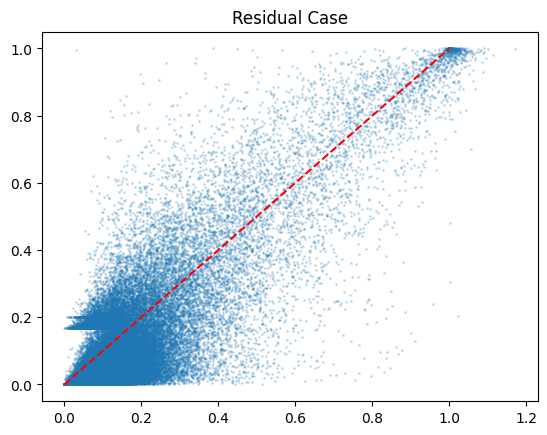

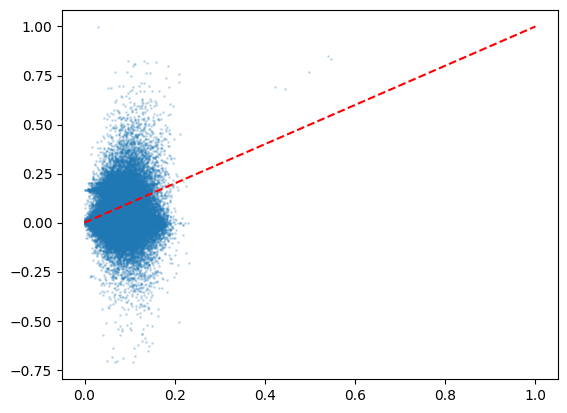

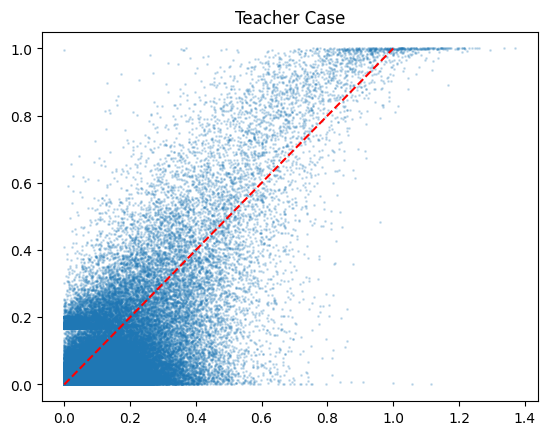

In [68]:
for cut0, cut1, cut2, cut3 in tests:
    mix = torch.zeros_like(allemb_)
    mix[:,:cut0] = allemb_[:,:cut0]
    mix[:,cut0:cut0+cut1] = quant4[:,cut0:cut0+cut1]
    mix[:,cut0+cut1:cut0+cut1+cut2] = quant2[:,cut0+cut1:cut0+cut1+cut2]
    mix[:,cut0+cut1+cut2:cut0+cut1+cut2+cut3] = quant1[:,cut0+cut1+cut2:cut0+cut1+cut2+cut3]
    data = (allemb_, mix[:660000], tp__, sp__)
    torch.cuda.empty_cache()
    configuration['percentage'] = 100
    configuration['target'] = 'residual'
    configuration['residual_scaler'] = 10
    configuration['num_clusters'] = [16]
    configuration['lr'] = 0.0001
    configuration['loss'] = 'l2'
    configuration['weight_decay'] = 1
    configuration['note'] = f'residual_l2_1res_{cut0}_{cut1}_{cut2}_{cut3}'
    trainer.train(configuration, data=data)
    torch.cuda.empty_cache()
    
    configuration['target'] = 'teacher'
    configuration['note'] = f'teachcer_l2_1res_{cut0}_{cut1}_{cut2}_{cut3}'
    trainer.train(configuration, data=data)
    torch.cuda.empty_cache()

528it [00:00, 597.55it/s]
528it [00:00, 642.15it/s]
528it [00:00, 642.03it/s]
528it [00:00, 605.47it/s]
528it [00:00, 640.62it/s]
528it [00:00, 639.55it/s]
528it [00:00, 638.36it/s]
528it [00:00, 607.80it/s]
528it [00:00, 644.52it/s]
528it [00:00, 647.04it/s]
528it [00:00, 603.27it/s]
528it [00:00, 641.30it/s]
528it [00:00, 638.06it/s]
528it [00:00, 633.31it/s]
528it [00:00, 614.12it/s]
528it [00:00, 634.19it/s]
528it [00:00, 635.77it/s]
528it [00:00, 605.62it/s]
528it [00:00, 638.27it/s]
528it [00:00, 633.50it/s]
528it [00:00, 595.08it/s]
528it [00:00, 633.21it/s]
528it [00:00, 639.07it/s]
528it [00:00, 609.16it/s]
528it [00:00, 630.20it/s]
528it [00:00, 640.16it/s]
528it [00:00, 642.50it/s]
528it [00:00, 607.76it/s]
528it [00:00, 641.52it/s]
528it [00:00, 638.81it/s]
528it [00:00, 605.90it/s]
528it [00:00, 633.31it/s]
528it [00:00, 637.58it/s]
528it [00:00, 640.23it/s]
528it [00:00, 607.32it/s]
528it [00:00, 646.86it/s]
528it [00:00, 644.18it/s]
528it [00:00, 609.56it/s]
528it [00:00

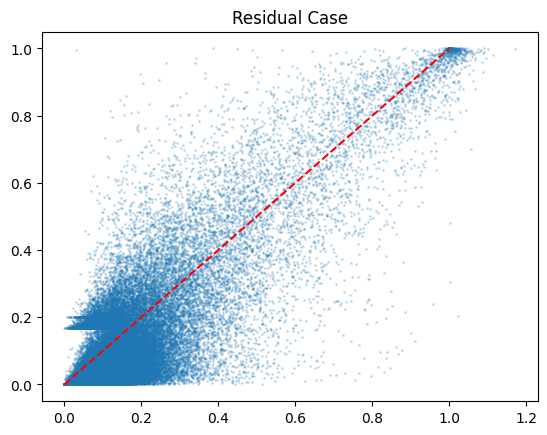

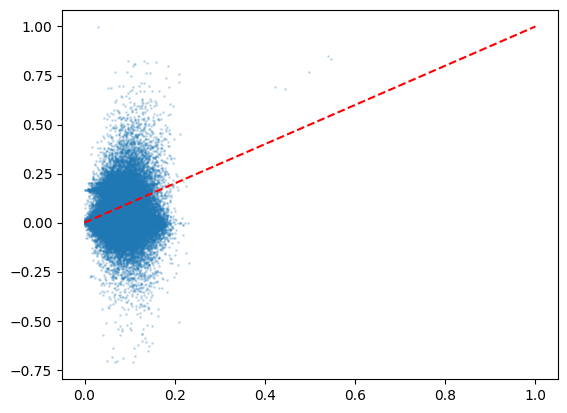

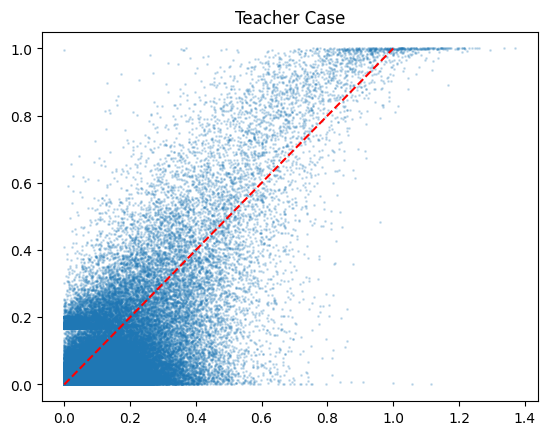

In [61]:
for cut0, cut1, cut2, cut3 in tests:
    mix = torch.zeros_like(allemb_)
    mix[:,:cut0] = allemb_[:,:cut0]
    mix[:,cut0:cut0+cut1] = quant4[:,cut0:cut0+cut1]
    mix[:,cut0+cut1:cut0+cut1+cut2] = quant2[:,cut0+cut1:cut0+cut1+cut2]
    mix[:,cut0+cut1+cut2:cut0+cut1+cut2+cut3] = quant1[:,cut0+cut1+cut2:cut0+cut1+cut2+cut3]
    data = (allemb_, mix[:660000], tp__, sp__)
    torch.cuda.empty_cache()
    configuration['percentage'] = 100
    configuration['target'] = 'residual'
    configuration['residual_scaler'] = 10
    configuration['num_clusters'] = [16]
    configuration['lr'] = 0.0001
    configuration['loss'] = 'l2'
    configuration['weight_decay'] = 1
    configuration['note'] = f'residual_l2_10res_{cut0}_{cut1}_{cut2}_{cut3}'
    trainer.train(configuration, data=data)
    torch.cuda.empty_cache()
    
    configuration['target'] = 'teacher'
    configuration['note'] = f'teachcer_l2_10res_{cut0}_{cut1}_{cut2}_{cut3}'
    trainer.train(configuration, data=data)
    torch.cuda.empty_cache()

In [148]:
cut0 = 0
cut1 = 2048
cut2 = 0
cut3 = max(0, 2048 - cut1 - cut2 - cut0)

In [156]:
mix = torch.zeros_like(allemb_)
mix[:,:cut0] = allemb_[:,:cut0]
mix[:,cut0:cut0+cut1] = quant4[:,cut0:cut0+cut1]
mix[:,cut0+cut1:cut0+cut1+cut2] = quant2[:,cut0+cut1:cut0+cut1+cut2]
mix[:,cut0+cut1+cut2:cut0+cut1+cut2+cut3] = quant1[:,cut0+cut1+cut2:cut0+cut1+cut2+cut3]


OutOfMemoryError: CUDA out of memory. Tried to allocate 2.52 GiB. GPU 

In [150]:
data = (allemb_, mix[:660000], tp__, sp__)

In [151]:
configuration['percentage'] = 100
configuration['target'] = 'residual'
configuration['residual_scaler'] = 10
configuration['num_clusters'] = [16]
configuration['lr'] = 0.0001
configuration['weight_decay'] = 1
configuration['note'] = f'old_{cut0}_{cut1}_{cut2}_{cut3}'

trainer.train(configuration, data=data)

528it [00:00, 611.39it/s]
528it [00:00, 628.03it/s]
528it [00:00, 621.68it/s]
528it [00:00, 596.52it/s]
528it [00:00, 632.93it/s]
528it [00:00, 633.30it/s]
528it [00:00, 636.46it/s]
528it [00:00, 599.20it/s]
528it [00:00, 622.63it/s]
528it [00:00, 631.94it/s]
528it [00:00, 594.85it/s]
528it [00:00, 631.59it/s]
528it [00:00, 618.51it/s]
528it [00:00, 633.36it/s]
528it [00:00, 582.22it/s]
528it [00:00, 619.11it/s]
528it [00:00, 629.22it/s]
528it [00:00, 601.46it/s]
528it [00:00, 634.47it/s]
528it [00:00, 627.95it/s]


In [106]:
mix = torch.zeros_like(allemb_)
mix[:,:cut0] = allemb_[:,:cut0]
mix[:,cut0:cut0+cut1] = quant4torch[:,cut0:cut0+cut1]
mix[:,cut0+cut1:cut0+cut1+cut2] = quant2torch[:,cut0+cut1:cut0+cut1+cut2]
mix[:,cut0+cut1+cut2:cut0+cut1+cut2+cut3] = quant1torch[:,cut0+cut1+cut2:cut0+cut1+cut2+cut3]


In [25]:
configuration['percentage'] = 100
configuration['target'] = 'residual'
configuration['residual_scaler'] = 10
configuration['num_clusters'] = [16]
configuration['lr'] = 0.001
configuration['weight_decay'] = 0
configuration['note'] = f'residual_lr={configuration["lr"]}_weightdecay={configuration["weight_decay"]}'

trainer.train(configuration, data=data)

528it [00:00, 668.43it/s]
528it [00:00, 667.96it/s]
528it [00:00, 671.55it/s]
528it [00:00, 635.91it/s]
528it [00:00, 671.12it/s]
528it [00:00, 679.24it/s]
528it [00:00, 656.21it/s]
528it [00:00, 630.98it/s]
528it [00:00, 674.99it/s]
528it [00:00, 677.05it/s]
528it [00:00, 639.47it/s]
528it [00:00, 674.97it/s]
528it [00:00, 677.81it/s]
528it [00:00, 668.13it/s]
528it [00:00, 628.59it/s]
528it [00:00, 658.84it/s]
528it [00:00, 662.15it/s]
528it [00:00, 627.59it/s]
528it [00:00, 661.25it/s]
528it [00:00, 657.79it/s]


| 4bit | 2bit | 1bit | <center>Bits/Emb <br>(4bit - 2bit - 1bit) | Accuracy (seed 0)  
|:-------------:|:-----------:|:------:| :------:| :------:|
| 2048 | 0 | 0  |   8192     | 0.07069   | 
| 1536 | 512 | 0  |   7168     | 0.07072   | 
| 1536 | 0 | 512  |   6656     | 0.07075   | 
| 1024 | 1024 | 0  |   6144     | 0.07076   | 
| 1024 | 512 | 512  |   5632     | 0.07079   | 
| 512 | 1536 | 0  |   5120     | 0.07081   | 
| 1024 | 0 | 1024  |   5120     | 0.07081   | 
| 256 | 1792 | 0  |   4608     | 0.07086   | 
| 512 | 1024 | 512  |   4608     | 0.07084   | 
| 512 | 768 | 768  |   4352     | 0.07084   | 
| 64 | 1984 | 0  |   4224     | 0.07093   | 
| 0 | 2048 | 0  |   4096     | 0.07115   | 
| 512 | 512 | 1024  |   4096     | 0.07086   | 
| 256 | 896 | 896  |   3712     | 0.07089   | 
| 512 | 0 | 1536  |   3584     | 0.07094   | 
| 256 | 768 | 1024  |   3584     | 0.07089   | 
| 256 | 0 | 1792  |   2816     | 0.07106   | 
| 64 | 0 | 1984  |   2240     | 0.07129   | 
| 0 | 0 | 2048  |   2048     | 0.07167   | 

In [26]:
16*64+4*256+2*512+1216

4288

In [121]:
torch.manual_seed(0)
indices = torch.randperm(allemb_.size(0))

### Residual prob case

In [100]:
predictionlist = []

for iii, state in enumerate(returns[1]):
    model, optimizer, writer, loss = state['model'], state['optimizer'], state['writer'], state['loss']
    prediction = torch.zeros(0, device=model.device)
    with torch.no_grad():
        model.eval()
        for embeddings_normal, embeddings_quant, teacher_probs, residual_prob in zip(*returns[2]):
            embeddings = embeddings_normal if iii % 2 == 0 else embeddings_quant
            label = teacher_probs if configuration['target'] == 'teacher' else residual_prob
            tp = teacher_probs
            output, losses = model(embeddings, label*configuration['residual_scaler'], tp, configuration['percentage'])
            prediction = torch.concatenate((prediction, output), dim=0)
        predictionlist.append(prediction)

In [122]:
predictionlist[0].shape

torch.Size([132000])

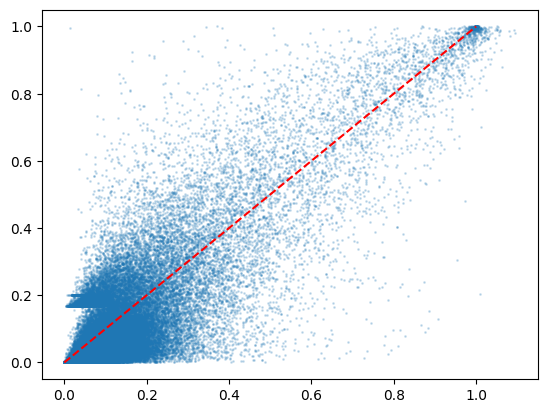

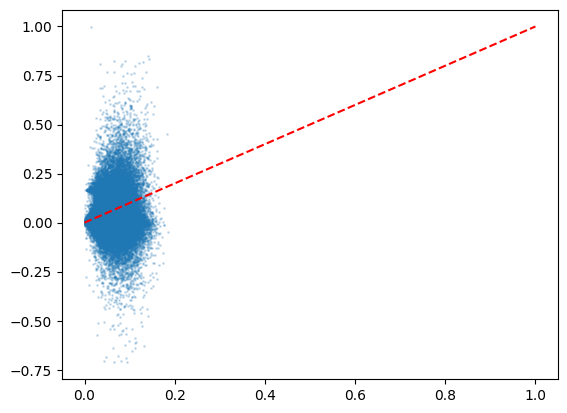

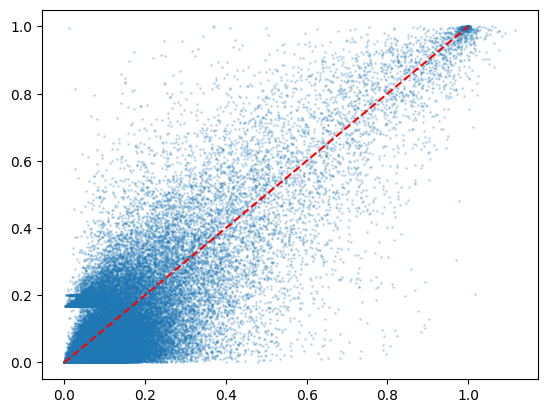

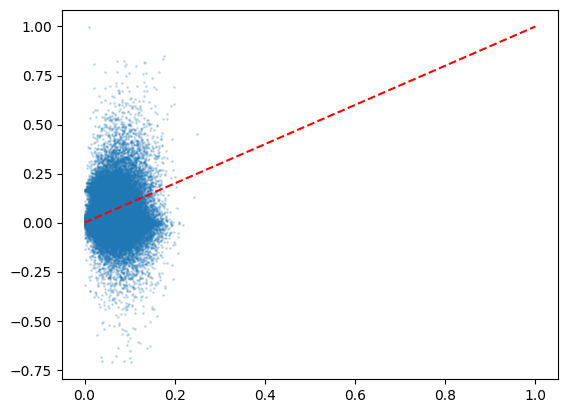

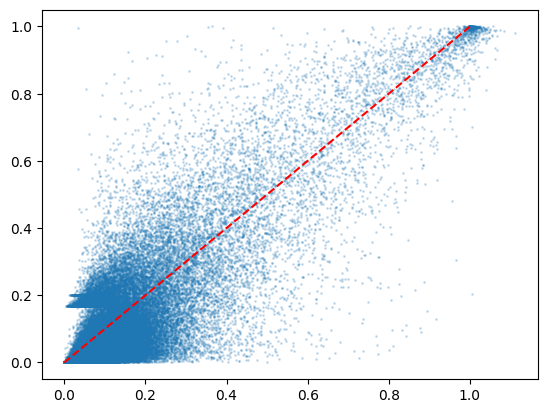

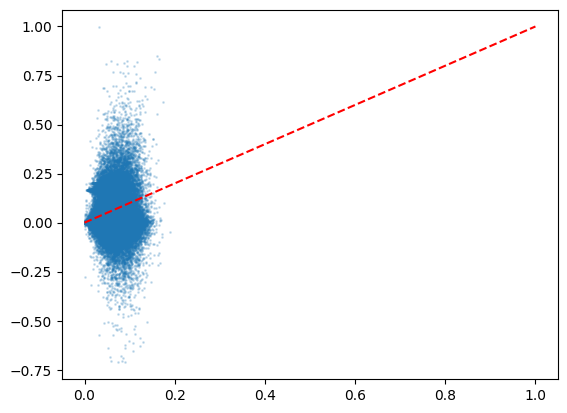

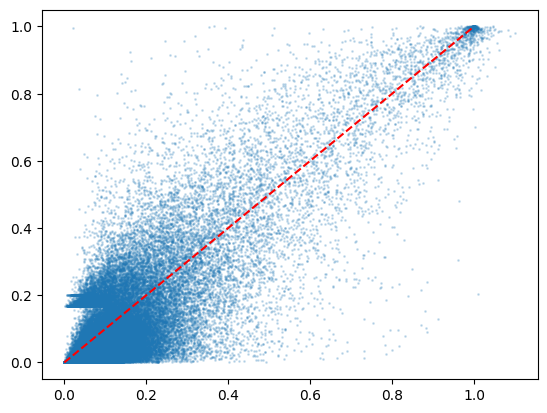

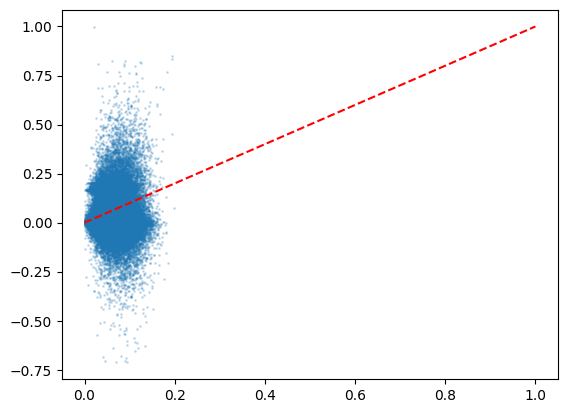

In [139]:
for pp in predictionlist:
    plt.figure()
    plt.scatter(allsprob[indices][-132000:] + (pp.cpu()/configuration['residual_scaler']), alltprob[indices][-132000:], s=1, alpha=0.2)
    plt.plot([0,1],[0,1], '--r')
    plt.figure()
    plt.scatter(pp.cpu()/configuration['residual_scaler'], allres[indices][-132000:], s=1, alpha=0.2)
    plt.plot([0,1],[0,1], '--r')

### Teacher prob case

In [147]:
predictionlist = []

for iii, state in enumerate(returns[1]):
    model, optimizer, writer, loss = state['model'], state['optimizer'], state['writer'], state['loss']
    prediction = torch.zeros(0, device=model.device)
    with torch.no_grad():
        model.eval()
        for embeddings_normal, embeddings_quant, teacher_probs, residual_prob in zip(*returns[2]):
            embeddings = embeddings_normal if iii % 2 == 0 else embeddings_quant
            label = teacher_probs if configuration['target'] == 'teacher' else residual_prob
            tp = teacher_probs
            output, losses = model(embeddings, label*configuration['residual_scaler'], tp, configuration['percentage'])
            prediction = torch.concatenate((prediction, output), dim=0)
        predictionlist.append(prediction)

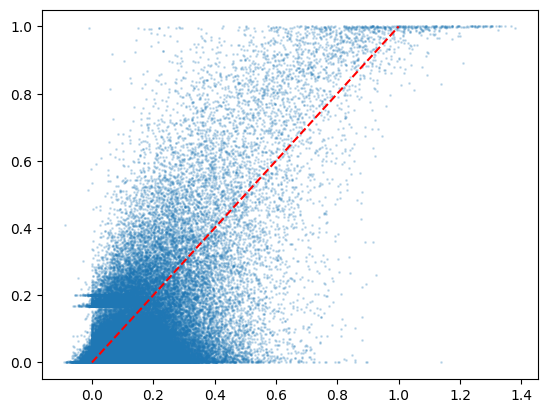

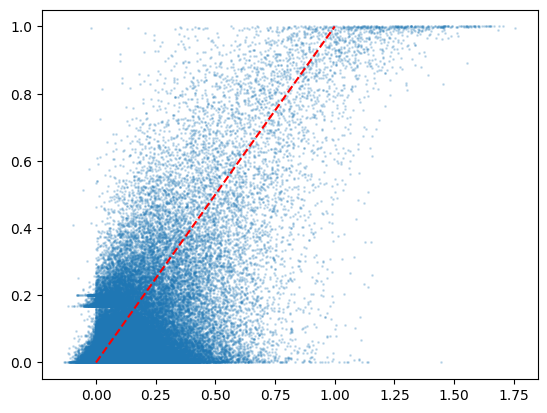

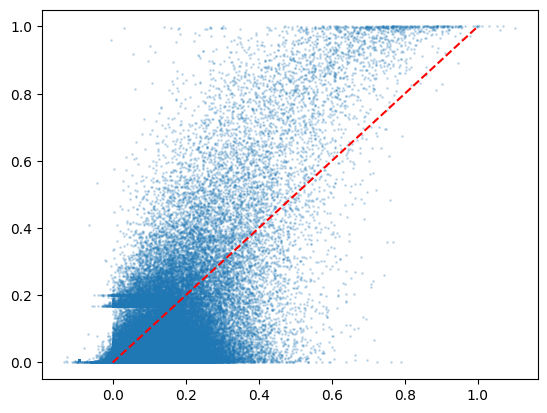

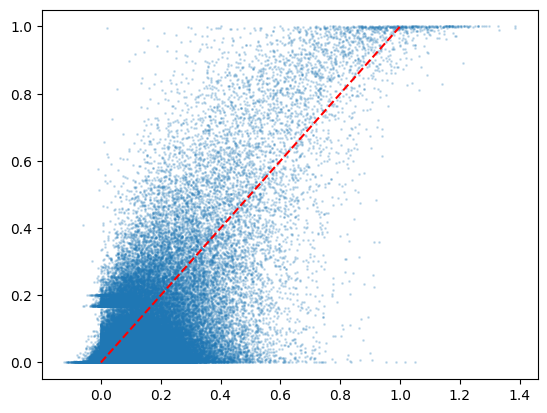

In [148]:
for pp in predictionlist:
    plt.figure()
    plt.scatter((pp.cpu()/configuration['residual_scaler']), alltprob[indices][-132000:], s=1, alpha=0.2)
    plt.plot([0,1],[0,1], '--r')

In [411]:
train_emb.shape

torch.Size([528, 1000, 2048])

In [398]:
predictions.shape

torch.Size([5000])

In [376]:
collect_test_outputs = torch.tensor(np.zeros((0)))

for 

torch.Size([132, 1000])

In [444]:
devs, means = train_emb.reshape(-1, 2048).std(dim=0), train_emb.reshape(-1, 2048).mean(dim=0)

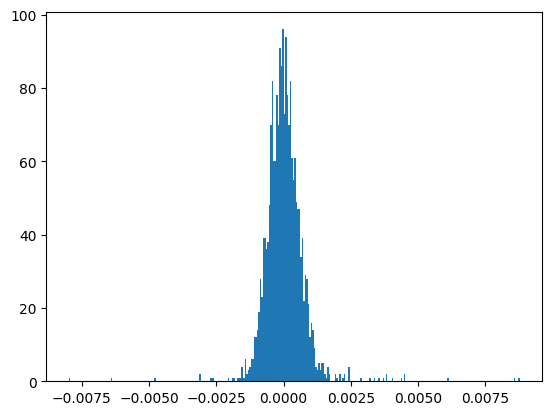

In [449]:
plt.hist(means.cpu(), bins=300);

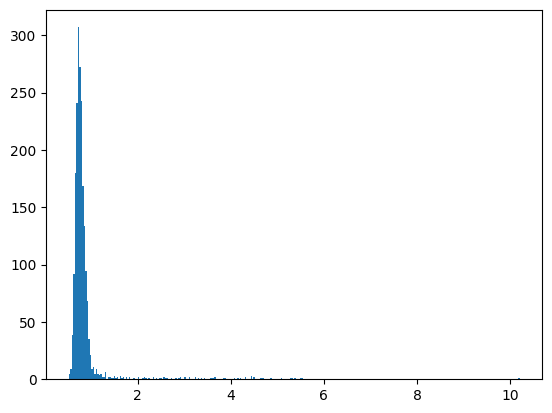

In [448]:
plt.hist(devs.cpu(), bins=300);


In [466]:
train_size

528

In [465]:
dataset.embeddings[indices][:train_size].shape

(528, 2048)

In [ ]:
normalized = train_emb - 

In [337]:
# Sanity checks
torch.manual_seed(0)
indices = torch.randperm(allemb_.size(0))
allemb__ = allemb_[indices]
batchsize = 1000
size = segment
allemb_batched = allemb__[:size].reshape(-1, batchsize, 2048)
alltprob_batched = alltprob[:size].reshape(-1, batchsize)
allres_batched = allres[:size].reshape(-1, batchsize)

train_size = int(allemb_batched.size(0) * 0.8)
train_emb, test_emb = allemb_batched[:train_size].to(device), allemb_batched[train_size:].to(device)
train_tprob, test_tprob = alltprob_batched[:train_size].to(device), alltprob_batched[train_size:].to(device)
train_res, test_res = allres_batched[:train_size].to(device), allres_batched[train_size:].to(device)

epochs = 20
BASELINE = [0]
# cluster_size = [2,4,8,16,32,64,128]
cluster_size = [64]
parallel_states = []
lr = 0.0001
oo = 'adamw'
# oo = 'sgd'
loss = 'kl'
# loss = 'l1'
# loss = 'l2'
residual_scaler = 10
for loss in ['l1', 'l2']:
    for cc in cluster_size:
        torch.manual_seed(0)
        model = multi_embedding(token_id, device, number_of_clusters=cc)
        optimizer = optim.SGD(model.parameters(), lr = lr, weight_decay=0.01) if oo == 'sgd' else optim.AdamW(model.parameters(), lr=lr, betas=(0.9, 0.99), weight_decay=1)
        location = f'/tmp/TBD'
        writer = SummaryWriter(location)
        parallel_states.append({
            'model' : model,
            'optimizer' : optimizer,
            'writer' : writer,
            'loss' : loss,
            'train_loss' : 0,
            'test_loss'  : 0
        })
step_count = 0
log_step = 10
validation_step = 100
for epoch in range(epochs):
    # Train loss
    for embeddings, teacher_probs, residual_prob in tqdm(zip(train_emb, train_tprob, train_res)):
        step_count += 1
        label = residual_prob
        tp = teacher_probs
        for state in parallel_states:
            model, optimizer, writer, loss = state['model'], state['optimizer'], state['writer'], state['loss']
            model.train()
            output, losses = model(embeddings, label*residual_scaler, tp)
            break
            # Batched loss
            lval = losses[loss].mean()
            optimizer.zero_grad()
            lval.backward()
            optimizer.step()
            state['train_loss'] += losses[loss].sum().item()

            # Test Loss
            if step_count % validation_step == 0:
                with torch.no_grad():
                    model.eval()
                    for embeddings, teacher_probs, residual_prob in zip(test_emb, test_tprob, test_res):
                        label = residual_prob
                        tp = teacher_probs
                        output, losses = model(embeddings, label*residual_scaler, tp)
                        state['test_loss'] += losses[loss].sum().item()
                    state['test_loss'] /= (test_emb.size(0)*test_emb.size(1))
                    writer.add_scalar(f'{loss.upper()}/Average Test Loss', state['test_loss'], step_count)
                    writer.add_scalar(f'{loss.upper()}/Overfitting indicator: Difference', state['test_loss'] - state['train_loss']/(log_step * batchsize), step_count)
                    writer.add_scalar(f'{loss.upper()}/Overfitting indicator: Ratio', state['test_loss'] / ( state['train_loss']/(log_step * batchsize)), step_count)
                    state['test_loss'] = 0
            if step_count % log_step == 0:
                writer.add_scalar(f'{loss.upper()}/Average Train Loss', state['train_loss']/(log_step * batchsize), step_count)
                state['train_loss'] = 0
        break


0it [00:00, ?it/s]


torch.Size([1000, 64])


0it [00:00, ?it/s]


torch.Size([1000, 64])


0it [00:00, ?it/s]


...

torch.Size([1000, 64])


0it [00:00, ?it/s]


torch.Size([1000, 64])


0it [00:00, ?it/s]

torch.Size([1000, 64])


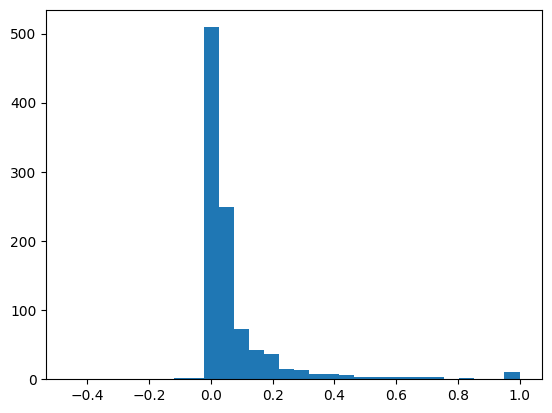

In [234]:
plt.hist(label.cpu(),bins=30);

In [110]:
state = parallel_states[1]
model, optimizer, writer, loss = state['model'], state['optimizer'], state['writer'], state['loss']


In [122]:
loss

'l1'

In [112]:
model.linear1.weight.data

tensor([[-0.0045,  0.0007, -0.0210,  ..., -0.0115,  0.0160, -0.0118],
        [-0.0088, -0.0120,  0.0197,  ..., -0.0103, -0.0152, -0.0121],
        [-0.0192, -0.0072, -0.0173,  ..., -0.0046,  0.0209, -0.0075],
        ...,
        [-0.0158, -0.0145,  0.0188,  ...,  0.0155, -0.0179, -0.0085],
        [-0.0206, -0.0158, -0.0027,  ...,  0.0200, -0.0063,  0.0128],
        [-0.0154,  0.0005, -0.0093,  ...,  0.0107, -0.0211, -0.0141]],
       device='cuda:0')

In [113]:
iterator = iter(zip(train_emb, train_tprob, train_res))

In [130]:
embeddings, teacher_probs, residual_prob = next(iterator)

In [131]:
label = residual_prob
tp = teacher_probs

In [134]:
label
# tp
# embeddings

tensor([ 2.7120e-05,  3.2471e-02,  8.9539e-02,  1.9299e-01,  3.1769e-02,
         5.3711e-03,  1.6205e-02,  2.6627e-02,  9.8724e-03,  5.4810e-02,
         7.6355e-02,  3.3661e-02,  7.7591e-03,  5.4026e-04,  4.7729e-02,
         3.9459e-02,  1.0368e-02,  2.9984e-02,  3.0176e-01,  1.7029e-02,
         6.7285e-01,  8.1909e-02,  4.1885e-03,  1.7900e-03,  5.5237e-03,
         1.2976e-01,  6.6406e-02,  1.0150e-01,  2.0828e-02,  4.2686e-03,
         3.0918e-03,  1.1121e-01,  2.9199e-01,  8.2474e-03,  1.5167e-02,
         2.9945e-03,  2.2858e-02,  8.0627e-02,  1.2951e-03,  8.4305e-03,
         1.0605e-02,  3.1952e-02,  5.1483e-02,  4.6997e-03,  1.9995e-01,
         1.3222e-02,  1.0364e-01,  5.9863e-01,  1.7932e-01,  8.8959e-03,
         3.3844e-02,  3.5767e-01,  9.0869e-01,  7.0129e-02,  4.8943e-03,
         2.9302e-04,  7.9407e-02,  2.9022e-02,  6.2402e-01,  2.5345e-02,
         9.0210e-02,  1.4087e-01,  7.7539e-01,  8.4473e-02,  1.5100e-01,
         1.2329e-02,  7.5098e-01,  6.1035e-02,  1.8

In [135]:
output, losses = model(embeddings, label*residual_scaler, tp)

In [137]:
output
# losses

tensor([ 4.0858e-02, -7.5491e-03, -3.1176e-03,  4.3114e-02,  5.1024e-02,
        -2.2577e-02,  2.8423e-02, -2.7318e-02,  1.4627e-02,  2.1515e-03,
        -1.4605e-02,  4.4811e-02,  4.6002e-03,  4.0400e-02, -3.1469e-02,
        -1.3210e-02, -9.6944e-04,  1.5800e-02,  1.0595e-03, -2.5988e-02,
        -2.1390e-03,  2.4784e-02, -2.3533e-02,  1.8920e-02,  2.6096e-02,
         1.0534e-02, -2.1923e-02, -4.4300e-02,  2.5508e-02,  4.5546e-03,
        -1.0788e-02,  6.1696e-02,  1.7978e-02, -3.3650e-02, -2.1013e-02,
        -3.6109e-02,  5.8657e-03, -3.4960e-02, -9.5768e-03, -2.0448e-02,
         9.3344e-03, -8.1703e-02, -2.9448e-03, -2.1761e-02,  3.0819e-02,
        -1.6280e-02, -1.0748e-03,  4.0689e-03, -1.4711e-03, -3.3666e-03,
        -8.8872e-03,  1.1276e-02,  3.7467e-02,  9.5275e-03,  3.7876e-02,
        -1.8738e-02, -2.7776e-04, -1.1266e-02,  2.7894e-02,  1.0993e-02,
         2.9976e-02, -1.6928e-02, -1.6864e-02, -5.3569e-03,  2.6328e-02,
        -3.1986e-03,  3.5813e-02, -5.1242e-02,  1.0

In [138]:
losses[loss].mean().item()

0.3507121801376343

In [139]:
lval = losses[loss].mean()
optimizer.zero_grad()
lval.backward()
optimizer.step()

In [140]:
model.linear1.weight.data

tensor([[-0.0046,  0.0005, -0.0212,  ..., -0.0117,  0.0159, -0.0120],
        [-0.0090, -0.0120,  0.0199,  ..., -0.0101, -0.0150, -0.0121],
        [-0.0193, -0.0074, -0.0174,  ..., -0.0048,  0.0207, -0.0077],
        ...,
        [-0.0159, -0.0147,  0.0190,  ...,  0.0157, -0.0177, -0.0087],
        [-0.0205, -0.0158, -0.0025,  ...,  0.0198, -0.0065,  0.0126],
        [-0.0156,  0.0007, -0.0091,  ...,  0.0109, -0.0209, -0.0142]],
       device='cuda:0')

In [168]:
model = multi_embedding(token_id, device, number_of_clusters=cc)
optimizer = optim.SGD(model.parameters(), lr = lr) if oo == 'sgd' else optim.Adam(model.parameters(), lr=lr, betas=(0.9, 0.99))

In [79]:
model.train()

multi_embedding(
  (linear1): Linear(in_features=2048, out_features=16, bias=False)
  (relu): ReLU()
)

In [155]:
model.number_of_clusters

0

In [154]:
(model(embeddings, label, tp))

(tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.

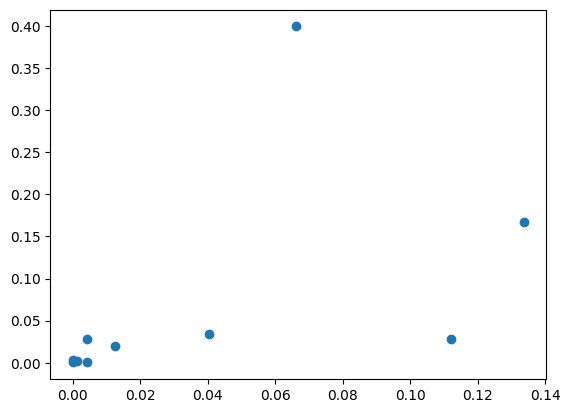

In [50]:
plt.scatter(student_probs.detach().cpu(),teacher_probs.detach().cpu())

In [9]:
file_id = 0
teacher_logits = (np.fromfile(os.path.join(LOCATION, f"{file_id:04d}_logit_t"),        dtype=np.float16)).reshape(-1, 100)
student_logits = (np.fromfile(os.path.join(LOCATION, f"{file_id:04d}_1618_student_logits"), dtype=np.float16)).reshape(-1, 100)
student_probs  = (np.fromfile(os.path.join(LOCATION, f"{file_id:04d}_1618_student_probs"), dtype=np.float16)).reshape(-1, 100)

In [10]:
teacher_logits.shape ,student_logits.shape ,student_probs.shape  

((1024000, 100), (6833, 100), (6833, 100))

In [11]:
student_probs

array([[8.232e-01, 1.080e-01, 3.553e-03, ..., 2.110e-05, 1.186e-05,
        4.351e-06],
       [9.634e-01, 2.179e-02, 1.111e-03, ..., 1.550e-06, 1.389e-05,
        6.437e-06],
       [6.622e-02, 2.700e-01, 2.898e-01, ..., 2.623e-04, 5.727e-04,
        4.703e-05],
       ...,
       [8.887e-05, 3.517e-06, 1.192e-07, ..., 0.000e+00, 0.000e+00,
        0.000e+00],
       [1.192e-07, 0.000e+00, 0.000e+00, ..., 0.000e+00, 0.000e+00,
        0.000e+00],
       [0.000e+00, 0.000e+00, 1.192e-07, ..., 0.000e+00, 0.000e+00,
        0.000e+00]], dtype=float16)

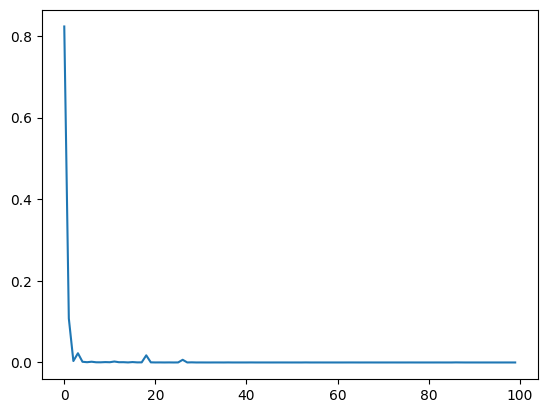

In [12]:
plt.plot(student_probs[0])

In [13]:
np.argsort(student_logits[0]), np.argsort(student_probs[0])


(array([78, 96, 91, 92, 57, 52, 93, 59, 69, 89, 60, 61, 81, 65, 95, 35, 85,
        99, 79, 50, 70, 73, 88, 68, 58, 75, 77, 83, 74, 32, 71, 66, 55, 98,
        94, 37, 46, 54, 84, 80, 90, 45, 49, 72, 31, 97, 43, 51, 64, 67, 24,
        29, 42, 44, 62, 38, 56, 39, 40, 48, 82, 76, 47, 22, 63, 34, 33, 30,
        27, 87, 20, 41, 25, 53, 14, 36, 21, 23, 86, 16, 17, 19, 28,  8,  7,
        10, 12,  5, 13,  9, 15,  4,  6, 11,  2, 26, 18,  3,  1,  0]),
 array([78, 96, 91, 92, 57, 52, 93, 59, 69, 89, 60, 61, 81, 65, 95, 35, 85,
        99, 79, 50, 70, 73, 88, 68, 58, 75, 77, 83, 74, 32, 71, 66, 55, 98,
        94, 37, 46, 54, 84, 80, 90, 45, 49, 72, 31, 97, 43, 51, 64, 67, 24,
        29, 42, 44, 62, 38, 56, 39, 40, 48, 82, 76, 47, 22, 63, 34, 33, 30,
        27, 87, 20, 41, 25, 53, 14, 36, 21, 23, 86, 16, 17, 19, 28,  8,  7,
        10, 12,  5, 13,  9, 15,  4,  6, 11,  2, 26, 18,  3,  1,  0]))

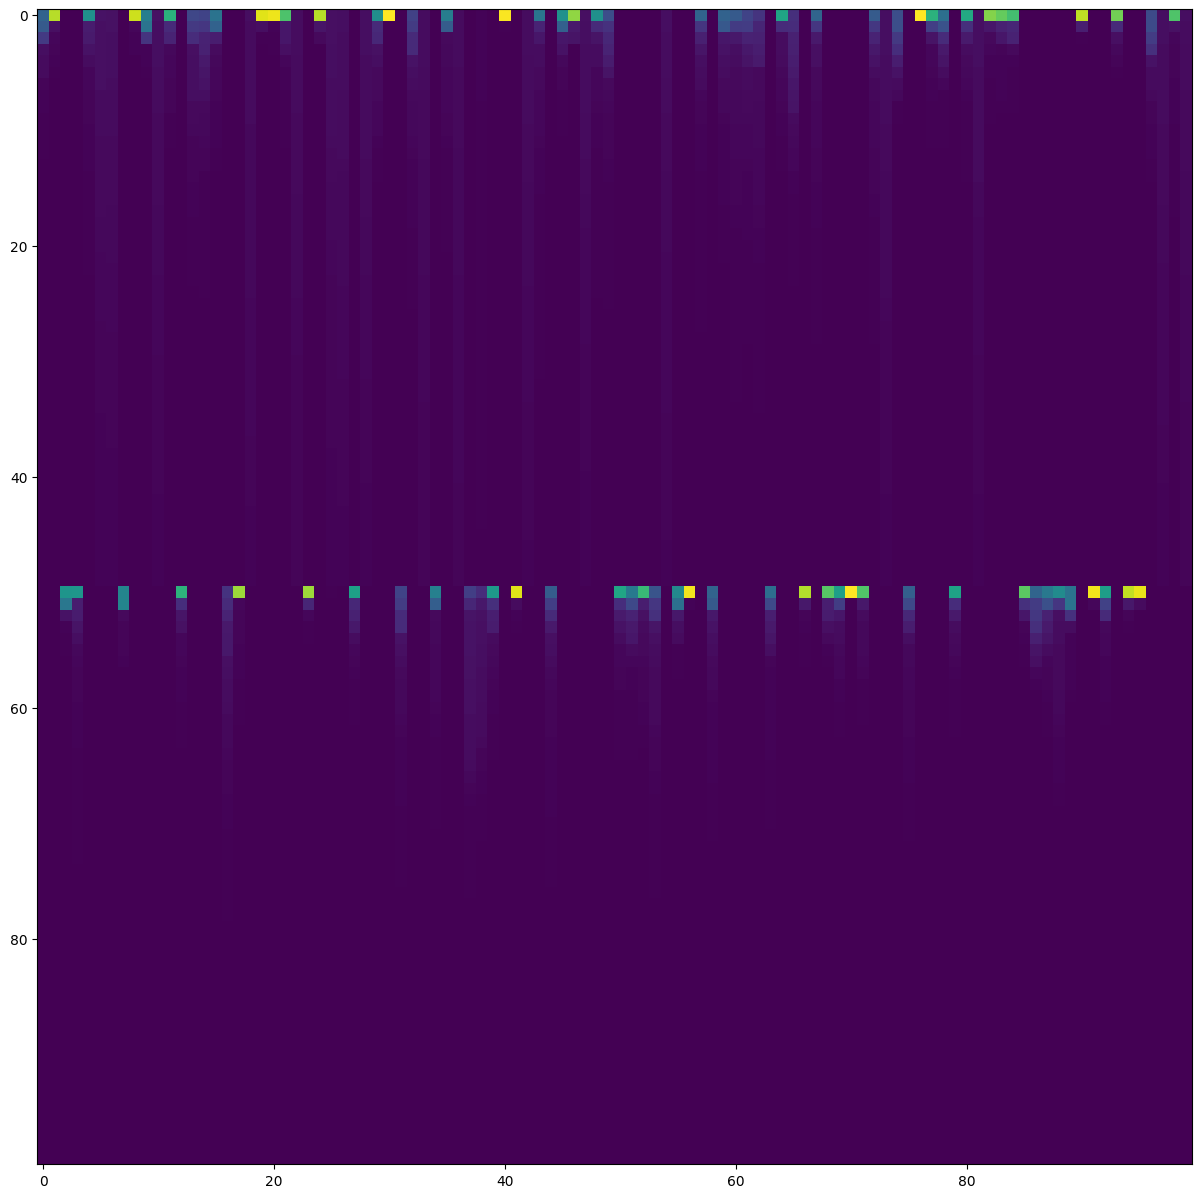

In [14]:
plt.figure(figsize=(15,15))
# plt.plot(student_logits[:1].T - student_logits[:1].min());
# plt.plot(10*student_probs[:1].T );
plt.imshow(alltprob[:100].detach().cpu().numpy().T*100+0.00001 );
# plt.yscale('log')

In [91]:
import torch.optim as optim
from torch.utils.tensorboard import SummaryWriter
import datetime
import time

# hyperparams = {
#     'lr' : 3e-8,
#     # 'target' : 'logit',        # residual logit or residual probability
#     'target' : 'probability',  
#     'weighted' : True,         # whether to multiply loss with parent probability or not 
#     'optimizer' : 'Adam',
#     'batch_size':  10000
# }

batch_size = int(1000000)
hyperparams = {
    'lr' : 1e-5,
    # 'target' : 'logit',        # residual logit or residual probability
    'target' : 'probability',  
    'weighted' : True,         # whether to multiply loss with parent probability or not 
    'optimizer' : 'SGD',
    'batch_size':  batch_size,
    'num_clusters' : 1,
    'bias' : True,
}

allemb_ = allemb - allemb.mean(dim=0, keepdims=True)
# print("Running experiments on token id", dataset.token_id, test_dataset.token_id, tokenizer.decode(dataset.token_id))
token_of_interest = token_id
for lr in [1e-2, 1e-3, 5e-2, 5e-3]:
    for num_clusters in [1, 8, 64]:
        hyperparams['lr'] = lr
        hyperparams['num_clusters'] = num_clusters
        torch.manual_seed(0)
        
        if hyperparams['bias']:
            if hyperparams['num_clusters'] == 1 : 
                model = linearlayer_withbias(token_of_interest, device)
            else:
                model = multi_embedding_withbias(token_of_interest, device, number_of_clusters=hyperparams['num_clusters'])
        else:
            if hyperparams['num_clusters'] == 1 : 
                model = linearlayer(token_of_interest, device)
            else:
                model = multi_embedding(token_of_interest, device, number_of_clusters=hyperparams['num_clusters'])
            
        optimizer = optim.SGD(model.parameters(), lr=hyperparams['lr'])
        n_epochs = 500
        location = f'mr/tensorboard/{tokenizer.decode(dataset.token_id)}/raw_prob_whitened/1000_multiplier_{hyperparams}'
        writer = SummaryWriter(location)
        
        loop = tqdm(range(n_epochs), desc="Progress")
        train_cache = 0
        test_cache  = 0
        
        for epoch in loop:
            epoch_loss = 0
            # Train loop
            embeddings = allemb_[:train_size]
            teacher_probs = alltprob[:train_size]
            student_probs = allsprob[:train_size]
            residual_prob = allres[:train_size]
            label = teacher_probs
    
            # Get teacher probabilities to pass to the model
            if hyperparams['weighted']:
                tp = teacher_probs
            else:
                tp = torch.ones_like(label) 
            optimizer.zero_grad()
            output, loss = model(embeddings, label*1000, tp)
            if epoch == 0: train_cache += (tp * torch.abs(label.to(torch.float32)*1000)).sum().item() # Loss(prediction, 0) = prediction.sum()
            # Batched loss
            loss.mean().backward()
            epoch_loss += loss.sum().item()
            optimizer.step()
            
            epoch_loss = epoch_loss/train_size
            if epoch == 0: train_cache /= train_size
            writer.add_scalar('Average Train Loss', epoch_loss/train_cache, epoch) # Display as ratio to baseline
            
            # Validation loop
            with torch.no_grad():
                validation_loss = 0
                embeddings = allemb_[train_size:]
                teacher_probs = alltprob[train_size:]
                student_probs = allsprob[train_size:]
                residual_prob = allres[train_size:]
                label = teacher_probs
                
                # Get teacher probabilities to pass to the model
                if hyperparams['weighted']:
                    tp = teacher_probs
                else:
                    tp = torch.ones_like(label)      
                
                output, loss = model(embeddings, label*1000, tp)
                if epoch == 0: test_cache += (tp * torch.abs(label.to(torch.float32)*1000)).sum().item()
                # Batched loss
                validation_loss += loss.sum().item()
                validation_loss = validation_loss / test_size
                if epoch == 0: test_cache /= test_size
                writer.add_scalar('Average Validation Loss', validation_loss/test_cache, epoch)


Progress: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 500/500 [00:31<00:00, 15.97it/s]


In [55]:
import torch.optim as optim
from torch.utils.tensorboard import SummaryWriter
import datetime
import time

# hyperparams = {
#     'lr' : 3e-8,
#     # 'target' : 'logit',        # residual logit or residual probability
#     'target' : 'probability',  
#     'weighted' : True,         # whether to multiply loss with parent probability or not 
#     'optimizer' : 'Adam',
#     'batch_size':  10000
# }

hyperparams = {
    'lr' : 1e-5,
    # 'target' : 'logit',        # residual logit or residual probability
    'target' : 'probability',  
    'weighted' : True,         # whether to multiply loss with parent probability or not 
    'optimizer' : 'SGD',
    'batch_size':  10000,
    'num_clusters' : 1,
    'bias' : True,
}

# print("Running experiments on token id", dataset.token_id, test_dataset.token_id, tokenizer.decode(dataset.token_id))
token_of_interest = token_id
for lr in [1e-5, 2e-5]:
    for num_clusters in [1, 2, 4, 10, 20, 50, 100]:
        hyperparams['lr'] = lr
        hyperparams['num_clusters'] = num_clusters
        torch.manual_seed(0)
        
        if hyperparams['bias']:
            if hyperparams['num_clusters'] == 1 : 
                model = linearlayer_withbias(token_of_interest, device)
            else:
                model = multi_embedding_withbias(token_of_interest, device, number_of_clusters=hyperparams['num_clusters'])
        else:
            if hyperparams['num_clusters'] == 1 : 
                model = linearlayer(token_of_interest, device)
            else:
                model = multi_embedding(token_of_interest, device, number_of_clusters=hyperparams['num_clusters'])
            
        optimizer = optim.SGD(model.parameters(), lr=hyperparams['lr'])#,momentum=0
        #optimizer = optim.Adam(model.parameters(), lr=hyperparams['lr'])
        n_epochs = 10
        experiment_name = "multi_cluster_center10"
        location = f'mr/tensorboard/temporary/{hyperparams["target"]}/{experiment_name}_{hyperparams}'
        location = f'mr/tensorboard/standardizing/{tokenizer.decode(dataset.token_id)}/new_{hyperparams}'
        # location = f'tensorboard/cluster_experiments/digits/new_{hyperparams}'
        writer = SummaryWriter(location)
        batch_size = int(1000000)
        loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=False, collate_fn=MRcollate)
        test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, shuffle=False, collate_fn=MRcollate)
        loop = tqdm(range(n_epochs), desc="Progress")
        train_cache = 0
        test_cache  = 0
        
        for epoch in loop:
            epoch_loss = 0
            # Train loop
            t1 = time.time()
            for batch in tqdm(loader): 
                t2 = time.time()
                print("Fetching takes", t2-t1," seconds")
                embeddings = batch['embedding']
                residual_prob = batch['residual']
                label = residual_prob
        
                # Get teacher probabilities to pass to the model
                if hyperparams['weighted']:
                    tp = batch['teacher_prob']
                else:
                    tp = torch.ones_like(label)    
                t1 = time.time()
                output, loss = model(embeddings, label*100, tp)
                t2 = time.time()
                print("Forward pass takes", t2-t1," seconds")
                if epoch == 0: train_cache += (tp * torch.abs(label.to(torch.float32)*100)).sum().item() # Loss(prediction, 0) = prediction.sum()
                # Batched loss
                t1 = time.time()
                loss.mean().backward()
                t2 = time.time()
                print("Backward pass takes", t2-t1," seconds")
                epoch_loss += loss.sum().item()
                t1 = time.time()
                optimizer.step()
                t2 = time.time()
                print("Optimizer step takes", t2-t1," seconds")
                t1 = time.time()
            
            epoch_loss = epoch_loss/train_size
            if epoch == 0: train_cache /= train_size
            writer.add_scalar('Average Train Loss', epoch_loss/train_cache, epoch) # Display as ratio to baseline
            
            # Validation loop
            with torch.no_grad():
                validation_loss = 0
                for batch in tqdm(test_loader): 
                    embeddings = batch['embedding']
                    residual_prob = batch['residual']
                    label = residual_prob
            
                    # Get teacher probabilities to pass to the model
                    if hyperparams['weighted']:
                        tp = batch['teacher_prob']
                    else:
                        tp = torch.ones_like(label)      
                    
                    output, loss = model(embeddings, label*100, tp)
                    if epoch == 0: test_cache += (tp * torch.abs(label*100)).mean().item()
                    # Batched loss
                    validation_loss += loss.sum().item()
                validation_loss = validation_loss / test_size
                if epoch == 0: test_cache /= test_size
                writer.add_scalar('Average Validation Loss', validation_loss/test_cache, epoch)
        # print('time',tall)


100%|█████████████████████████████████████████████| 1/1 [00:18<00:00, 18.58s/it]


Fetching takes 18.52225661277771  seconds
Forward pass takes 0.020850419998168945  seconds
Backward pass takes 0.0010113716125488281  seconds
Optimizer step takes 0.0004024505615234375  seconds



Progress:  10%|███▍                              | 1/10 [00:37<05:33, 37.06s/it]


KeyboardInterrupt: 

In [59]:
test_dataset.dataset.embeddings.shape

(661621, 2048)

In [56]:
embeddings.shape

torch.Size([132325, 2048])

In [52]:
loss

tensor([[2.7343e+01, 7.8180e+00, 1.0640e+00,  ..., 5.1227e-07, 4.0337e-07,
         1.0255e-05],
        [9.6422e+01, 3.2477e-02, 1.3954e-05,  ..., 4.6712e-10, 5.2859e-10,
         2.8125e-10],
        [2.5325e-05, 2.5325e-05, 2.5325e-05,  ..., 1.4681e-09, 2.4779e-09,
         2.6446e-09],
        ...,
        [2.0682e+00, 1.6082e+00, 9.7658e-01,  ..., 1.4103e-07, 1.4103e-07,
         1.1302e-07],
        [1.7404e-01, 1.7404e-01, 1.7404e-01,  ..., 0.0000e+00, 0.0000e+00,
         0.0000e+00],
        [2.1415e+01, 4.2209e+00, 1.5521e+00,  ..., 5.5974e-06, 1.2912e-05,
         6.3247e-06]], device='cuda:0')

In [108]:
batch.keys()

dict_keys(['embedding', 'residual', 'offset'])

In [76]:
import torch.optim as optim
from torch.utils.tensorboard import SummaryWriter
import datetime
import time

# hyperparams = {
#     'lr' : 3e-8,
#     # 'target' : 'logit',        # residual logit or residual probability
#     'target' : 'probability',  
#     'weighted' : True,         # whether to multiply loss with parent probability or not 
#     'optimizer' : 'Adam',
#     'batch_size':  10000
# }

hyperparams = {
    'lr' : 1e-5,
    # 'target' : 'logit',        # residual logit or residual probability
    'target' : 'probability',  
    'weighted' : True,         # whether to multiply loss with parent probability or not 
    'optimizer' : 'SGD',
    'batch_size':  10000,
    'num_clusters' : 1,
    'bias' : True,
}
print("Running experiments on token id", dataset.token_id, test_dataset.token_id, tokenizer.decode(dataset.token_id))
for lr in [1e-5, 2e-5]:
    for num_clusters in [1, 2, 4, 10, 20, 50, 100]:
        hyperparams['lr'] = lr
        hyperparams['num_clusters'] = num_clusters
        torch.manual_seed(0)
        
        if hyperparams['bias']:
            if hyperparams['num_clusters'] == 1 : 
                model = linearlayer_withbias(token_of_interest, 'cuda:0')
            else:
                model = multi_embedding_withbias(token_of_interest, 'cuda:0', number_of_clusters=hyperparams['num_clusters'])
        else:
            if hyperparams['num_clusters'] == 1 : 
                model = linearlayer(token_of_interest, 'cuda:0')
            else:
                model = multi_embedding(token_of_interest, 'cuda:0', number_of_clusters=hyperparams['num_clusters'])
            
        optimizer = optim.SGD(model.parameters(), lr=hyperparams['lr'])#,momentum=0
        #optimizer = optim.Adam(model.parameters(), lr=hyperparams['lr'])
        n_epochs = 300
        experiment_name = "multi_cluster_center10"
        location = f'tensorboard/temporary/{hyperparams["target"]}/{experiment_name}_{hyperparams}'
        location = f'tensorboard/standardizing/{tokenizer.decode(dataset.token_id)}/new_{hyperparams}'
        # location = f'tensorboard/cluster_experiments/digits/new_{hyperparams}'
        writer = SummaryWriter(location)
        
        tall=0
        batch_size=np.minimum(hyperparams['batch_size'], len(dataset))
        
        # loader = torch.utils.data.DataLoader(dataset, batch_size=10000, shuffle=False, collate_fn=collate)
        loop = tqdm(range(n_epochs), desc="Progress")
        train_cache = 0
        test_cache  = 0
        
        for epoch in loop:
            epoch_loss = 0
            # Train loop
            for i in np.arange(len(dataset)/batch_size, dtype=np.int8): 
                start=i*batch_size;
                end  =start+batch_size
                if start==len(dataset): continue
                example_ids=(dataset.informations['example_id'][start:end]  )
                token_pos  =(dataset.informations['positions' ][start:end]  )
                embeddings =(dataset.informations['embeddings'][start:end,:])
                
                token_of_interest_rank =(dataset.informations['ranks' ][start:end]  )
        
                # Get residual probabilities to pass to the model        
                # residual_prob = residual_probs[example_ids.cpu(), token_pos.cpu(), token_of_interest_rank.cpu()]
                residual_prob = residual_probs[example_ids, token_pos, token_of_interest_rank]
        
                # residual_logit = residuals[example_ids, token_pos, token_of_interest_rank]
                
                # if hyperparams['target'] == 'logit':
                #     label = residual_logit
                # else:
                label = residual_prob
        
                # Get teacher probabilities to pass to the model
                if hyperparams['weighted']:
                    # tp = teacher_probs[example_ids.cpu(), token_pos.cpu(), token_of_interest_rank.cpu()]
                    tp = teacher_probs[example_ids, token_pos, token_of_interest_rank]
                    
                else:
                    tp = torch.ones_like(label)    
                
                output, loss = model(embeddings, label.unsqueeze(1)*100, tp.unsqueeze(1))
                if epoch == 0: train_cache += (tp.unsqueeze(1) * torch.abs(label.unsqueeze(1)*100)).sum().item()
                # Batched loss
                loss.mean().backward()
                epoch_loss += loss.sum().item()
                optimizer.step()
            epoch_loss = epoch_loss/(len(dataset))
            if epoch == 0: train_cache /= len(dataset)
            writer.add_scalar('Average Train Loss', epoch_loss/train_cache, epoch)
        
            
            # Validation loop
            with torch.no_grad():
                example_ids=(test_dataset.informations['example_id'])
                token_pos  =(test_dataset.informations['positions' ])
                embeddings =(test_dataset.informations['embeddings'])
                token_of_interest_rank =(test_dataset.informations['ranks' ])
                # Get residual probabilities to pass to the model        
                residual_prob = residual_probs[example_ids, token_pos, token_of_interest_rank]
                # residual_logit = residuals[example_ids, token_pos, token_of_interest_rank]
                
                # if hyperparams['target'] == 'logit':
                #     label = residual_logit
                # else:
                label = residual_prob
        
                # Get teacher probabilities to pass to the model
                if hyperparams['weighted']:
                    tp = teacher_probs[example_ids, token_pos, token_of_interest_rank]
                else:
                    tp = torch.ones_like(label)    
                
                output, loss = model(embeddings, label.unsqueeze(1)*100, tp.unsqueeze(1))
                if epoch == 0: test_cache += (tp.unsqueeze(1) * torch.abs(label.unsqueeze(1)*100)).mean().item()
                # Batched loss
                validation_loss = loss.mean().item()
                writer.add_scalar('Average Validation Loss', validation_loss/test_cache, epoch)
        # print('time',tall)


Running experiments on token id 1142 1142  set


Progress:  18%|███              | 54/300 [00:01<00:08, 28.29it/s]


KeyboardInterrupt: 

In [51]:
len()

156619

In [36]:
tp.device

device(type='cuda', index=0)

## Analyses

In [63]:
ID.shape

torch.Size([28000, 1024])

In [62]:
T_ID.shape

torch.Size([28000, 1024, 10])

In [66]:
((T_ID[...,:i+1].reshape(-1,i+1) == token_of_interest).reshape(-1, 1024, i+1))

torch.Size([28000, 1024, 1])

In [67]:
myind = ((ID[:,0] != 0).reshape(-1, 1, 1).repeat(1, 1024, i+1) * ((T_ID[...,:i+1].reshape(-1,i+1) == token_of_interest).reshape(-1, 1024, i+1))).nonzero()

In [72]:
myind.shape

torch.Size([8474, 3])

In [71]:
(ID[myind[...,0], myind[...,1]] == token_of_interest).sum()

tensor(5071, device='cuda:1')

In [75]:
5071/8927

0.5680519771479781

In [74]:
(ID == token_of_interest).sum()

tensor(8927, device='cuda:1')

In [57]:
i=0
(ID[:,0] != 0).reshape(-1,1).repeat(1, i+1) * T_ID[...,:i+1].reshape(-1,i+1) == token_of_interest

RuntimeError: The size of tensor a (28000) must match the size of tensor b (28672000) at non-singleton dimension 0

In [55]:
for i in range(10):
    (ID[:,0] != 0).reshape(-1,1).repeat(1, i) * T_ID[...,:i+1].reshape(-1,i) == token_of_interest

tensor([[[False, False, False,  ..., False, False, False],
         [False, False, False,  ..., False, False, False],
         [False, False, False,  ..., False, False, False],
         ...,
         [False, False, False,  ..., False, False, False],
         [False, False, False,  ..., False, False, False],
         [False, False, False,  ..., False, False, False]],

        [[False, False, False,  ..., False, False, False],
         [False, False, False,  ..., False, False, False],
         [False, False, False,  ..., False, False, False],
         ...,
         [False, False, False,  ..., False, False, False],
         [False, False, False,  ..., False, False, False],
         [False, False, False,  ..., False, False, False]],

        [[False, False, False,  ..., False, False, False],
         [False, False, False,  ..., False, False, False],
         [False, False, False,  ..., False, False, False],
         ...,
         [False, False, False,  ..., False, False, False],
         [

In [54]:
hit_rate_report(token_of_interest)

		OVERALL
top 1 	--- tensor(0.5740, device='cuda:1')
top 2 	--- tensor(0.6690, device='cuda:1')
top 3 	--- tensor(0.7084, device='cuda:1')
top 4 	--- tensor(0.7314, device='cuda:1')
top 5 	--- tensor(0.7477, device='cuda:1')
top 6 	--- tensor(0.7627, device='cuda:1')
top 7 	--- tensor(0.7737, device='cuda:1')
top 8 	--- tensor(0.7823, device='cuda:1')
top 9 	--- tensor(0.7906, device='cuda:1')
top 10 	--- tensor(0.7962, device='cuda:1')

		Train
top 1 	--- tensor(0.5768, device='cuda:1')
top 2 	--- tensor(0.6715, device='cuda:1')
top 3 	--- tensor(0.7111, device='cuda:1')
top 4 	--- tensor(0.7344, device='cuda:1')
top 5 	--- tensor(0.7502, device='cuda:1')
top 6 	--- tensor(0.7650, device='cuda:1')
top 7 	--- tensor(0.7763, device='cuda:1')
top 8 	--- tensor(0.7845, device='cuda:1')
top 9 	--- tensor(0.7931, device='cuda:1')
top 10 	--- tensor(0.7988, device='cuda:1')

		Test
top 1 	--- tensor(0.5489, device='cuda:1')
top 2 	--- tensor(0.6467, device='cuda:1')
top 3 	--- tensor(0.6844,

In [53]:
## Cumulative hit-rate probabilities given Ground truth == token_of_interest
token_of_interest = 7900
def hit_rate_report(token_of_interest=token_of_interest):
    ex_id, tpos = (ID == token_of_interest).nonzero().split(1,dim=-1)
    ex_id, tpos = ex_id.squeeze(), tpos.squeeze()
    my_filter = ex_id < 25000
    print('\t\tOVERALL')
    for rank in range(1, 11): 
        print('top', rank, '\t---', (T_ID[ex_id, tpos].squeeze()[..., :rank] == token_of_interest).sum() / ex_id.shape[0])
    print('\n\t\tTrain')
    for rank in range(1, 11): 
        print('top', rank, '\t---', (T_ID[ex_id[my_filter], tpos[my_filter]].squeeze()[..., :rank] == token_of_interest).sum() / ex_id[my_filter].shape[0])
    print('\n\t\tTest')
    for rank in range(1, 11): 
        print('top', rank, '\t---', (T_ID[ex_id[~my_filter], tpos[~my_filter]].squeeze()[..., :rank] == token_of_interest).sum() / ex_id[~my_filter].shape[0])
def hit_rate_histogram_helper(token_of_interest=token_of_interest):
    ex_id, tpos = (ID == token_of_interest).nonzero().split(1,dim=-1)
    ex_id, tpos = ex_id.squeeze(), tpos.squeeze()
    if len(ex_id.shape) == 0 or 0 in ex_id.shape:
        return [0 for _ in range(10)]
    return [((T_ID[ex_id, tpos].squeeze()[..., :rank] == token_of_interest).sum() / ex_id.shape[0]).item() for rank in range(1, 11)]
def hit_rate_histogram():
    data = np.zeros((256000, 10))
    for i in tqdm(range(256000)):
        token_data = hit_rate_histogram_helper(i)
        data[i] = token_data
    return data
# full_data = hit_rate_histogram()

In [71]:
full_data[digit_ids]

array([[0.77439988, 0.87812662, 0.91157734, 0.9265976 , 0.93602419,
        0.95613867, 0.96055907, 0.96447361, 0.97043604, 0.97391814],
       [0.72949785, 0.8412925 , 0.89376074, 0.9134686 , 0.93449354,
        0.94411707, 0.96066827, 0.96754688, 0.97280926, 0.97685897],
       [0.6017673 , 0.69934255, 0.78125775, 0.83749771, 0.88115317,
        0.90689903, 0.92802531, 0.95560986, 0.96491957, 0.97360665],
       [0.5632866 , 0.64104611, 0.69940865, 0.80076593, 0.85157478,
        0.89445305, 0.92539942, 0.94467443, 0.95917225, 0.97124267],
       [0.55426812, 0.64752555, 0.73747474, 0.78064793, 0.85078144,
        0.89113015, 0.92101502, 0.93736136, 0.95440263, 0.96943128],
       [0.58568871, 0.66508979, 0.70760632, 0.77327722, 0.80482751,
        0.8591522 , 0.90482754, 0.93698877, 0.95757282, 0.96669894],
       [0.52710569, 0.59958005, 0.64167756, 0.69109529, 0.71293879,
        0.74477965, 0.78321284, 0.8591674 , 0.88462502, 0.93574107],
       [0.55289257, 0.63739246, 0.6721101

In [64]:
(ID == 100).nonzero().split(1,dim=-1)[0]

torch.Size([0])

In [52]:
hit_rate_report(100)

		OVERALL
top 1 	--- tensor(nan, device='cuda:1')
top 2 	--- tensor(nan, device='cuda:1')
top 3 	--- tensor(nan, device='cuda:1')
top 4 	--- tensor(nan, device='cuda:1')
top 5 	--- tensor(nan, device='cuda:1')
top 6 	--- tensor(nan, device='cuda:1')
top 7 	--- tensor(nan, device='cuda:1')
top 8 	--- tensor(nan, device='cuda:1')
top 9 	--- tensor(nan, device='cuda:1')
top 10 	--- tensor(nan, device='cuda:1')

		Train
top 1 	--- tensor(nan, device='cuda:1')
top 2 	--- tensor(nan, device='cuda:1')
top 3 	--- tensor(nan, device='cuda:1')
top 4 	--- tensor(nan, device='cuda:1')
top 5 	--- tensor(nan, device='cuda:1')
top 6 	--- tensor(nan, device='cuda:1')
top 7 	--- tensor(nan, device='cuda:1')
top 8 	--- tensor(nan, device='cuda:1')
top 9 	--- tensor(nan, device='cuda:1')
top 10 	--- tensor(nan, device='cuda:1')

		Test
top 1 	--- tensor(nan, device='cuda:1')
top 2 	--- tensor(nan, device='cuda:1')
top 3 	--- tensor(nan, device='cuda:1')
top 4 	--- tensor(nan, device='cuda:1')
top 5 	--- 

<BarContainer object of 256000 artists>

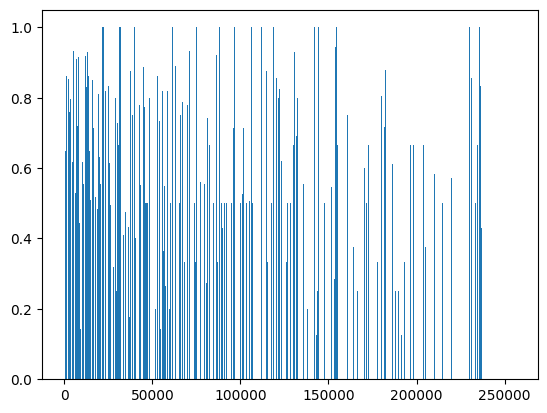

In [27]:
plt.figure()
plt.bar(np.arange(256000), full_data[:, 9])

In [41]:
np.nan_to_num(full_data, 100)

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [37]:
problematic = ((full_data[:, 9] < 0.2) * (full_data[:, 9] > 0)).nonzero()[0]

In [38]:
tokenizer.convert_ids_to_tokens(problematic)

['<0xCE>',
 '<0xDC>',
 '<0xE0>',
 '<0xE5>',
 '<0xE6>',
 '<0xE8>',
 '<0xE9>',
 '▁bec',
 '▁の',
 '▁proble',
 '▁happ',
 '▁commun',
 '▁eas',
 '▁whe',
 '▁ris',
 '▁necess',
 '▁sou',
 '▁wer',
 '▁posi',
 '▁hu',
 '▁wan',
 '▁famili',
 '▁mach',
 'weet',
 'ITEM',
 '▁ens',
 '▁jus',
 '▁Wik',
 '▁creat',
 '▁calcul',
 '▁chall',
 '▁immedi',
 '▁possib',
 '▁administ',
 'Just',
 '▁progra',
 '▁scre',
 '▁Just',
 '▁sty',
 '▁vic',
 '▁objec',
 '▁occas',
 '▁accep',
 '▁Produ',
 'Home',
 '▁neu',
 '▁wea',
 'Did',
 '▁moder',
 'ラン',
 '▁While',
 '▁Most',
 '▁Like',
 '▁Even',
 '▁scienti',
 '▁occup',
 'nah',
 'Discussion',
 'Before',
 '▁proces',
 '▁Prom',
 '▁sli',
 '▁entr',
 'voir',
 'Liter',
 'Fran',
 'Summary',
 '▁dedic',
 'Have',
 '▁Many',
 '▁ah',
 'Many',
 '▁Although',
 '▁foc',
 '▁Have',
 '▁Dav',
 'ynch',
 '▁Because',
 '▁stret',
 '▁Look',
 '▁Tag',
 '▁Requ',
 'While',
 '▁tat',
 'Most',
 '▁Such',
 '▁Did',
 'hibition',
 '▁incl',
 'Was',
 'Identi',
 '▁emphas',
 '▁conj',
 '▁coe',
 'Even',
 'Track',
 '▁According',
 '▁mari',

In [15]:
## Gemma7 per-token loss: Given ground truth == token_of_interest, what is the cross entropy loss of the predictions
loss_fn = torch.nn.CrossEntropyLoss(reduce=False)
locations_train = train_dataset.informations['example_id'], train_dataset.informations['positions'], train_dataset.informations['ranks']
locations_test = test_dataset.informations['example_id'], test_dataset.informations['positions'], test_dataset.informations['ranks']
loss_train= loss_fn(TL[locations_train[0], locations_train[1]], locations_train[2])
loss_test = loss_fn(TL[locations_test[0], locations_test[1]], locations_test[2])
losses = torch.concatenate((loss_train, loss_test), dim=0)

/home/igli/.local/lib/python3.10/site-packages/torch/nn/_reduction.py:42: UserWarning: size_average and reduce args will be deprecated, please use reduction='none' instead.
  warnings.warn(warning.format(ret))


In [67]:
losses

tensor([11.0625,  4.6953,  0.4929,  ...,  3.4199,  5.2812,  3.1367],
       device='cuda:1', dtype=torch.float16)

In [16]:
ALL_GT = ((ID[:,0] != 0).unsqueeze(1) * (ID == token_of_interest)).nonzero().split(1, dim=1)

In [17]:
ALL_GT[0].shape

torch.Size([7842, 1])

In [74]:
hits[:,0]

tensor([   0,    1,    2,  ..., 7839, 7840, 7841], device='cuda:1')

In [75]:
TL[hits[:,0]].squeeze().shape

torch.Size([7018, 1024, 10])

In [18]:
misses = (T_ID[ALL_GT[0], ALL_GT[1]].squeeze() != token_of_interest).all(dim=1).nonzero().squeeze()

In [19]:
ID[ALL_GT[0][misses].squeeze(), ALL_GT[1][misses].squeeze()]

tensor([7900, 7900, 7900, 7900, 7900, 7900, 7900, 7900, 7900, 7900, 7900, 7900,
        7900, 7900, 7900, 7900, 7900, 7900, 7900, 7900, 7900, 7900, 7900, 7900,
        7900, 7900, 7900, 7900, 7900, 7900, 7900, 7900, 7900, 7900, 7900, 7900,
        7900, 7900, 7900, 7900, 7900, 7900, 7900, 7900, 7900, 7900, 7900, 7900,
        7900, 7900, 7900, 7900, 7900, 7900, 7900, 7900, 7900, 7900, 7900, 7900,
        7900, 7900, 7900, 7900, 7900, 7900, 7900, 7900, 7900, 7900, 7900, 7900,
        7900, 7900, 7900, 7900, 7900, 7900, 7900, 7900, 7900, 7900, 7900, 7900,
        7900, 7900, 7900, 7900, 7900, 7900, 7900, 7900, 7900, 7900, 7900, 7900,
        7900, 7900, 7900, 7900, 7900, 7900, 7900, 7900, 7900, 7900, 7900, 7900,
        7900, 7900, 7900, 7900, 7900, 7900, 7900, 7900, 7900, 7900, 7900, 7900,
        7900, 7900, 7900, 7900, 7900, 7900, 7900, 7900, 7900, 7900, 7900, 7900,
        7900, 7900, 7900, 7900, 7900, 7900, 7900, 7900, 7900, 7900, 7900, 7900,
        7900, 7900, 7900, 7900, 7900, 79

In [54]:
all_ranks = torch.zeros(ALL_GT[0].shape[0], device=device).long()

In [55]:
hits = (T_ID[ALL_GT[0].squeeze(), ALL_GT[1].squeeze()] == token_of_interest).nonzero()

In [56]:
all_ranks[hits[:,0]] = hits[:,1]

In [57]:
all_ranks[misses.cpu()] = 10

In [59]:
all_ranks.shape

torch.Size([7842])

In [49]:
hits.shape, ALL_GT[0].shape

(torch.Size([7018, 2]), torch.Size([7842, 1]))

In [61]:
np.log(256000-10)

12.45289366019874

In [34]:
(T_ID[ALL_GT[0], ALL_GT[1]] != token_of_interest).all(dim=-1).nonzero()

tensor([[  34,    0],
        [  38,    0],
        [  58,    0],
        ...,
        [7804,    0],
        [7819,    0],
        [7824,    0]], device='cuda:1')

In [32]:
all_ranks = T_ID[ALL_GT[0], ALL_GT[1]]

torch.Size([7842, 1])

In [29]:
T_ID[ALL_GT[0].squeeze(), ALL_GT[1].squeeze()][1]

tensor([  7900, 235290,  34492,   5358,    108,  32885,  72691,  67837,  26480,
         14845], device='cuda:1', dtype=torch.int32)

In [20]:
torch.log_softmax(TL[ALL_GT[0][misses].squeeze(), ALL_GT[1][misses].squeeze()], dim=-1).min()

tensor(-8.5156, device='cuda:1', dtype=torch.float16)

Maybe we should set constant to something higher?

In [21]:
misses.shape

torch.Size([824])

In [22]:
TL.shape

torch.Size([28000, 1024, 10])

In [84]:
loss_fn(torch.log_softmax(torch.concatenate((TL[ALL_GT[0][misses].squeeze(), ALL_GT[1][misses].squeeze()], TL[ALL_GT[0][misses].squeeze(), ALL_GT[1][misses].squeeze()].min(dim=-1).values.unsqueeze(1)*4), dim=-1), dim=-1), all_ranks[misses])

tensor([7.9550e+02, 4.6100e+02, -0.0000e+00, 4.7825e+02, 6.0700e+02, 7.3050e+02,
        4.5250e+02, -0.0000e+00, 4.5600e+02, 4.4344e+01, 4.0000e+02, -0.0000e+00,
        2.3750e+02, 7.0850e+02, 4.8225e+02, 6.1650e+02, -0.0000e+00, 4.8450e+02,
        7.0650e+02, -0.0000e+00, 1.3461e+01, 1.2588e+02, -0.0000e+00, 5.3250e+02,
        -0.0000e+00, 7.5750e+02, 3.1500e+02, -0.0000e+00, -0.0000e+00, 4.4700e+02,
        -0.0000e+00, 5.5050e+02, -0.0000e+00, 3.5925e+02, 6.9150e+02, 2.9475e+02,
        -0.0000e+00, 5.6850e+02, -0.0000e+00, 7.7200e+02, 2.4275e+02, 7.6950e+02,
        7.7900e+02, 7.4650e+02, 1.7715e-04, -0.0000e+00, 7.6350e+02, 1.5650e+02,
        2.0212e+02, 6.6850e+02, 1.0381e+02, -0.0000e+00, 4.6275e+02, 5.9100e+02,
        4.9150e+02, -0.0000e+00, -0.0000e+00, -0.0000e+00, -0.0000e+00, -0.0000e+00,
        -0.0000e+00, 8.0300e+02, 6.2950e+02, -0.0000e+00, 7.3000e+02, 1.1921e-07,
        8.0050e+02, 6.4950e+02, -0.0000e+00, -0.0000e+00, -0.0000e+00, 2.7575e+02,
        -0.0000

In [64]:
min_teacher_logits = TL[ALL_GT[0][misses].squeeze(), ALL_GT[1][misses].squeeze()].min(dim=-1).values

In [71]:
torch.log_softmax(torch.concatenate((TL[ALL_GT[0][misses].squeeze(), ALL_GT[1][misses].squeeze()], min_teacher_logits.unsqueeze(1).repeat(1,256000-10)), dim=1), dim=1).min()

tensor(-12.4688, device='cuda:1', dtype=torch.float16)

In [55]:
torch.tensor(10).repeat(824).shape

torch.Size([824])

In [37]:
tokenizer.convert_ids_to_tokens(digit_ids)

['1', '2', '3', '4', '5', '6', '7', '8', '9', '0']

In [50]:
for i in range(1,11):
    print(f"\tInformation for digit {i%10}")
    hit_rate_report(digit_ids[i-1])

	Information for digit 1
		OVERALL
top 1 	--- tensor(0.7744, device='cuda:1')
top 2 	--- tensor(0.8781, device='cuda:1')
top 3 	--- tensor(0.9116, device='cuda:1')
top 4 	--- tensor(0.9266, device='cuda:1')
top 5 	--- tensor(0.9360, device='cuda:1')
top 6 	--- tensor(0.9561, device='cuda:1')
top 7 	--- tensor(0.9606, device='cuda:1')
top 8 	--- tensor(0.9645, device='cuda:1')
top 9 	--- tensor(0.9704, device='cuda:1')
top 10 	--- tensor(0.9739, device='cuda:1')

		Train
top 1 	--- tensor(0.7743, device='cuda:1')
top 2 	--- tensor(0.8782, device='cuda:1')
top 3 	--- tensor(0.9116, device='cuda:1')
top 4 	--- tensor(0.9266, device='cuda:1')
top 5 	--- tensor(0.9361, device='cuda:1')
top 6 	--- tensor(0.9561, device='cuda:1')
top 7 	--- tensor(0.9606, device='cuda:1')
top 8 	--- tensor(0.9645, device='cuda:1')
top 9 	--- tensor(0.9704, device='cuda:1')
top 10 	--- tensor(0.9738, device='cuda:1')

		Test
top 1 	--- tensor(0.7753, device='cuda:1')
top 2 	--- tensor(0.8774, device='cuda:1')


Significant difficulty in predicting digits 5 and 7 (?)